In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [2]:
obj <- readRDS("cellplex2_soupX.rds")

In [3]:
hvg <- read.csv("cellplex2.bigsur.hvg.csv", row.names = 1)

In [4]:
meta <- read.csv("cellplex2.adata.obs.metadata.csv", row.names=1)
colnames(meta)
head(meta)

[1] "orig_ident"                  "n_genes"                    
 [3] "n_genes_by_counts"           "log1p_n_genes_by_counts"    
 [5] "total_counts"                "log1p_total_counts"         
 [7] "pct_counts_in_top_50_genes"  "pct_counts_in_top_100_genes"
 [9] "pct_counts_in_top_200_genes" "pct_counts_in_top_500_genes"
[11] "total_counts_mt"             "log1p_total_counts_mt"      
[13] "pct_counts_mt"               "total_counts_ribo"          
[15] "log1p_total_counts_ribo"     "pct_counts_ribo"            
[17] "total_counts_hb"             "log1p_total_counts_hb"      
[19] "pct_counts_hb"               "leiden"                     
[21] "leiden_res_0.10"             "leiden_res_0.20"            
[23] "leiden_res_0.50"             "cell_type"

,orig_ident,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,leiden,leiden_res_0.10,leiden_res_0.20,leiden_res_0.50,cell_type
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>
AAACCCAGTGCCCAGT-1,pMFP_1,2329,2329,7.753624,6236,8.738255,23.90956,35.45542,48.04362,64.68890,...,7.049255,18.45734,0,0,0,2,2,2,1,Fibroblasts
AAACGAAAGTAGCATA-1,pMFP_1,3739,3739,8.226841,12612,9.442483,23.57279,34.01522,45.50428,60.56137,...,7.694393,17.40406,0,0,0,2,2,2,1,Fibroblasts
AAACGAAGTCGTACAT-1,pMFP_1,2199,2199,7.696213,6652,8.802823,30.36681,45.53518,56.85508,70.30968,...,7.642044,31.31389,0,0,0,0,0,0,0,Basal
AAACGAAGTCGTGGAA-1,pMFP_1,3072,3072,8.030410,9522,9.161466,27.16866,41.31485,51.82735,64.57677,...,7.942718,29.55261,0,0,0,4,4,4,5,LumSec
AAACGAATCAATGTCG-1,pMFP_1,3221,3221,8.077758,10393,9.248984,23.83335,35.24488,48.09968,63.49466,...,7.512618,17.60801,0,0,0,2,2,9,13,Fibroblasts
AAAGAACCACAATGAA-1,pMFP_1,2766,2766,7.925519,9436,9.152393,31.37982,47.60492,58.43578,70.30521,...,8.055793,33.39339,0,0,0,4,4,4,5,LumSec


In [5]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACCCAGTGCCCAGT-1,pMFP_1,2.100706,18.45734,0,2,Fibroblasts
AAACGAAAGTAGCATA-1,pMFP_1,1.998097,17.40406,0,2,Fibroblasts
AAACGAAGTCGTACAT-1,pMFP_1,4.013830,31.31389,0,0,Basal
AAACGAAGTCGTGGAA-1,pMFP_1,2.846041,29.55261,0,4,LumSec
AAACGAATCAATGTCG-1,pMFP_1,1.510632,17.60801,0,2,Fibroblasts
AAAGAACCACAATGAA-1,pMFP_1,3.062738,33.39339,0,4,LumSec


In [6]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type,nCount_SCT,nFeature_SCT,SCT_snn_res.0.1,seurat_clusters
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>,<fct>,<fct>
AAACCCAGTGCCCAGT-1,SeuratProject,6118.687,2329,pMFP_1,2.100706,18.45734,0,2,Fibroblasts,6118.687,2329,2,2
AAACGAAAGTAGCATA-1,SeuratProject,12329.153,3733,pMFP_1,1.998097,17.40406,0,2,Fibroblasts,12329.153,3733,2,2
AAACGAAGTCGTACAT-1,SeuratProject,6518.036,2194,pMFP_1,4.013830,31.31389,0,0,Basal,6518.036,2194,0,0
AAACGAAGTCGTGGAA-1,SeuratProject,9334.139,3071,pMFP_1,2.846041,29.55261,0,4,LumSec,9334.139,3071,5,5
AAACGAATCAATGTCG-1,SeuratProject,10169.872,3217,pMFP_1,1.510632,17.60801,0,2,Fibroblasts,10169.872,3217,2,2
AAAGAACCACAATGAA-1,SeuratProject,9252.262,2761,pMFP_1,3.062738,33.39339,0,4,LumSec,9252.262,2761,5,5


### test

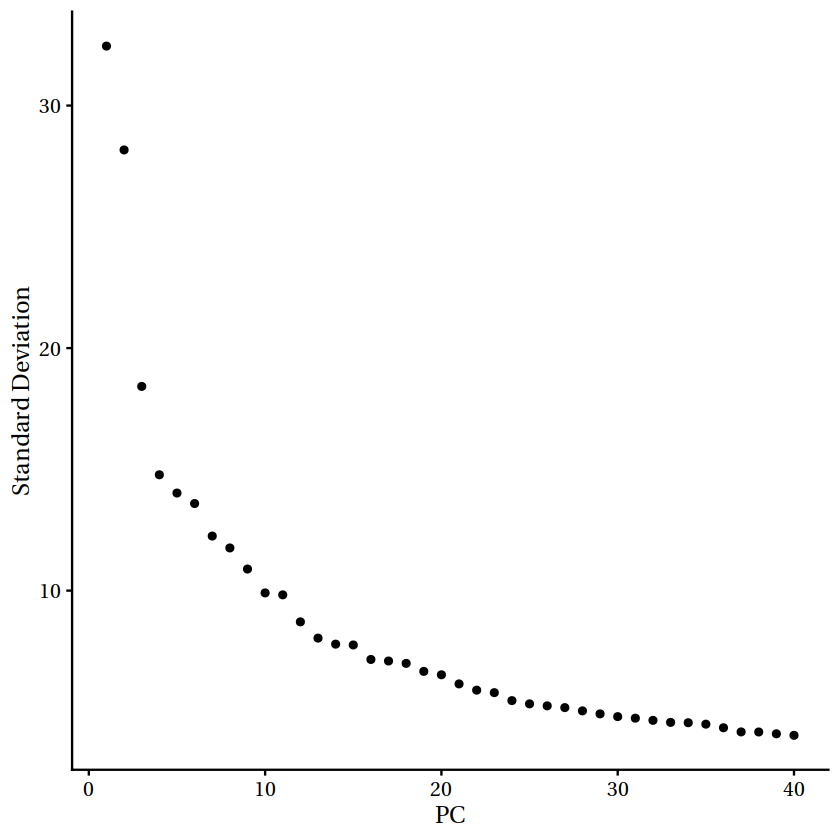

In [12]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

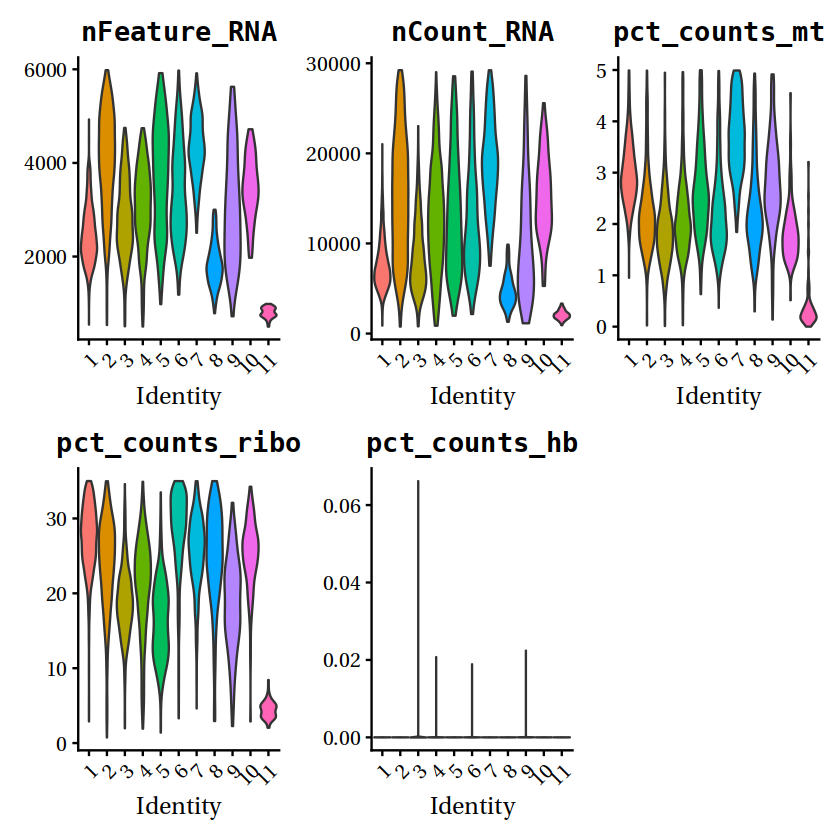

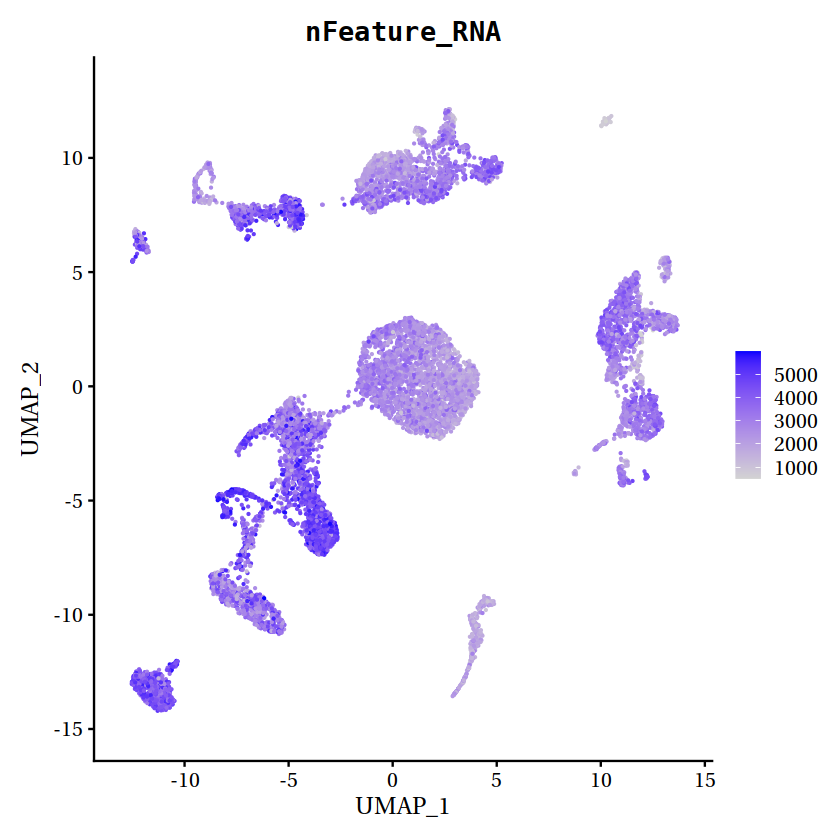

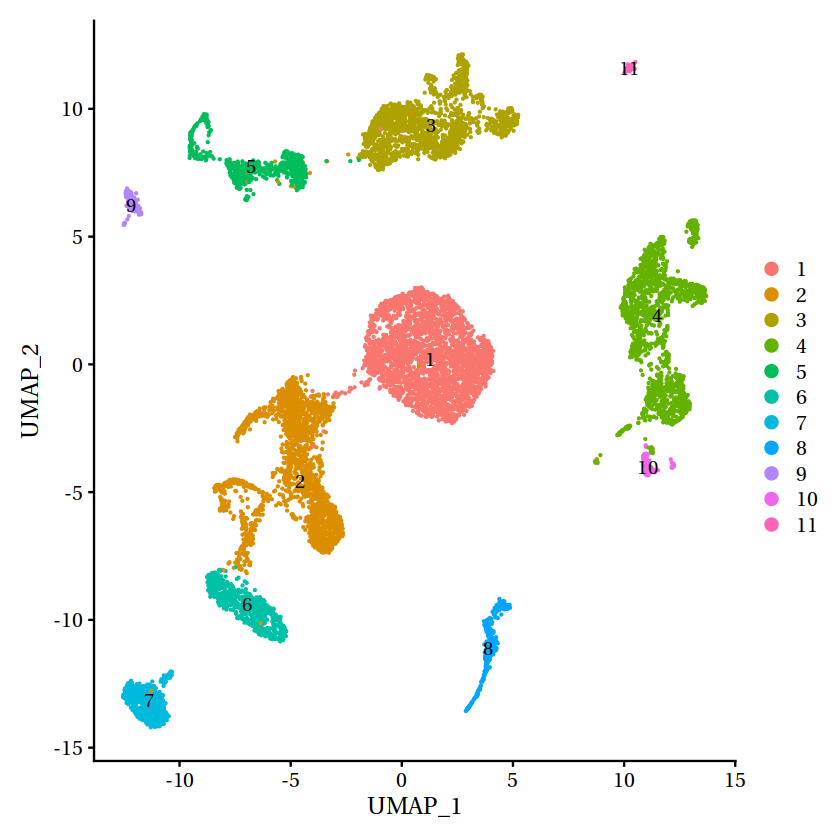

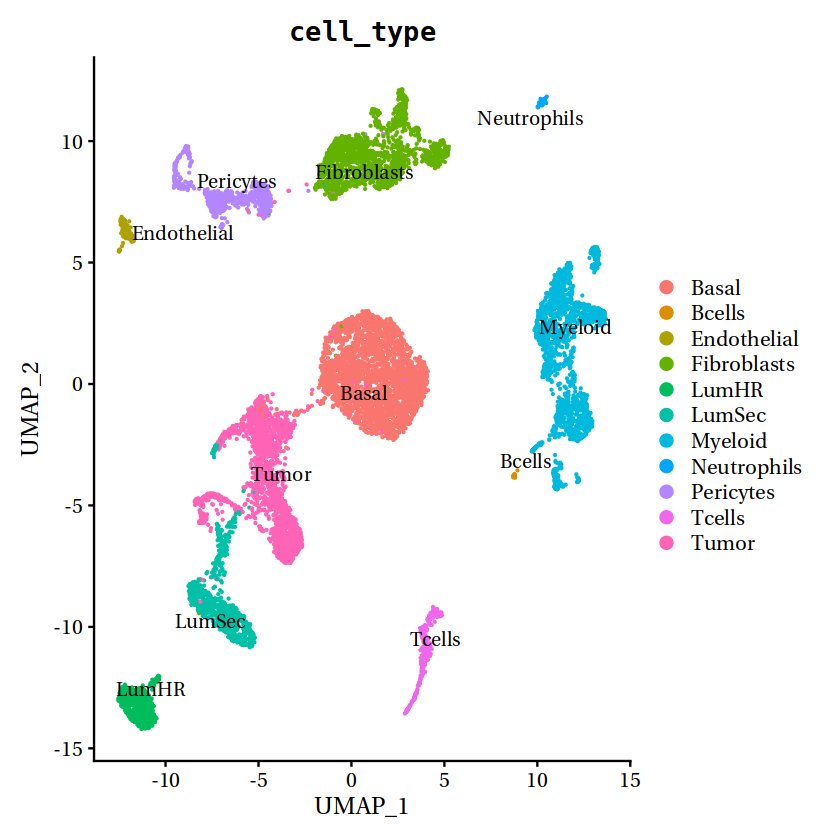

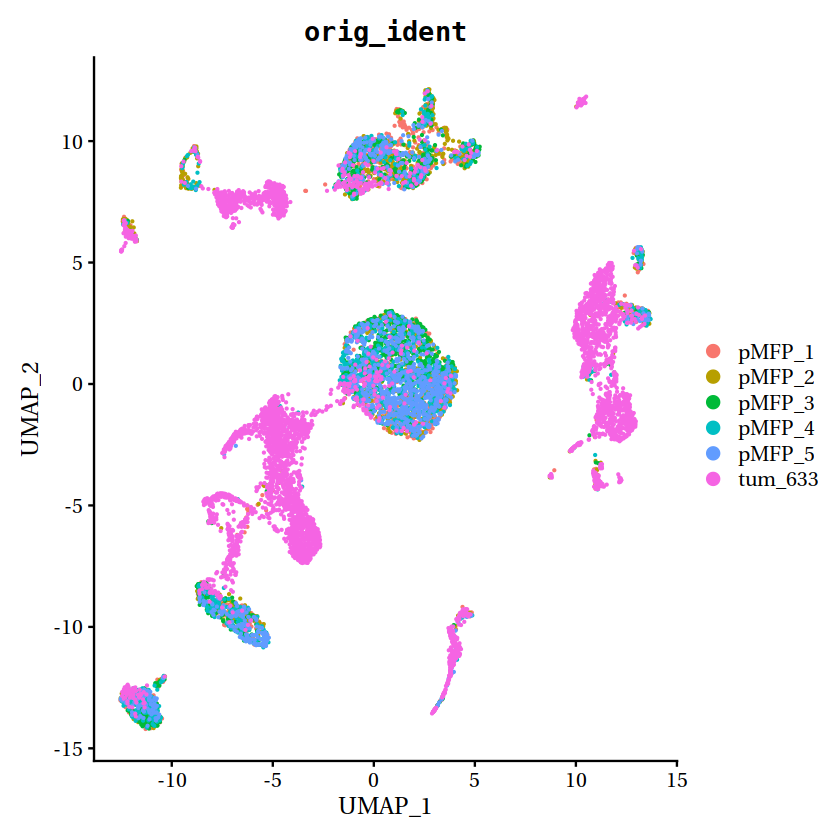

In [13]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, algorithm = 4, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

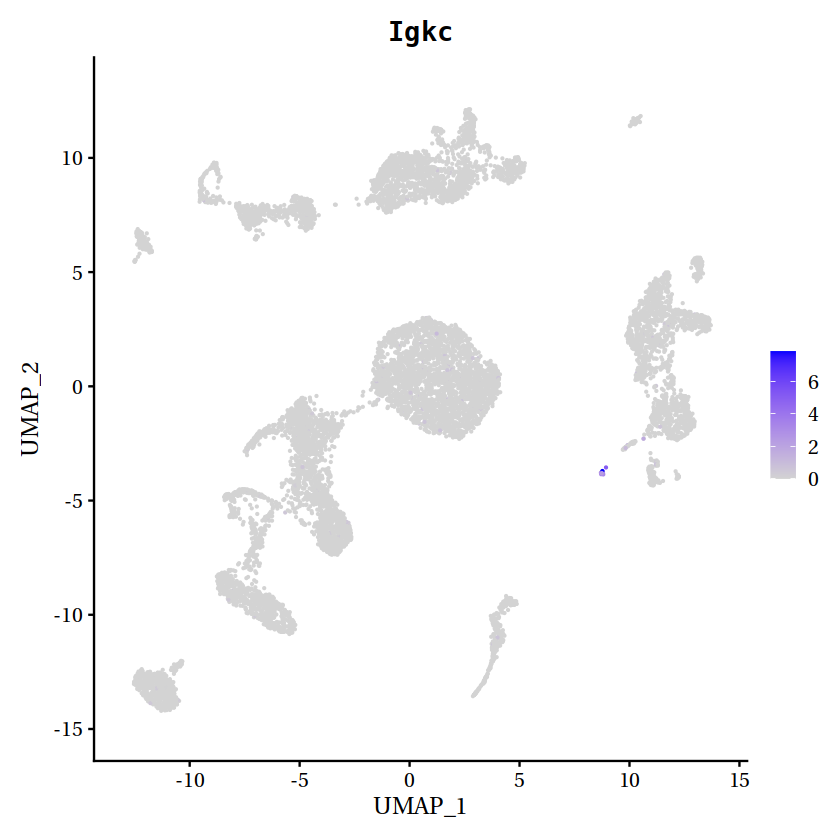

In [14]:
FeaturePlot(obj, "Igkc")

### real

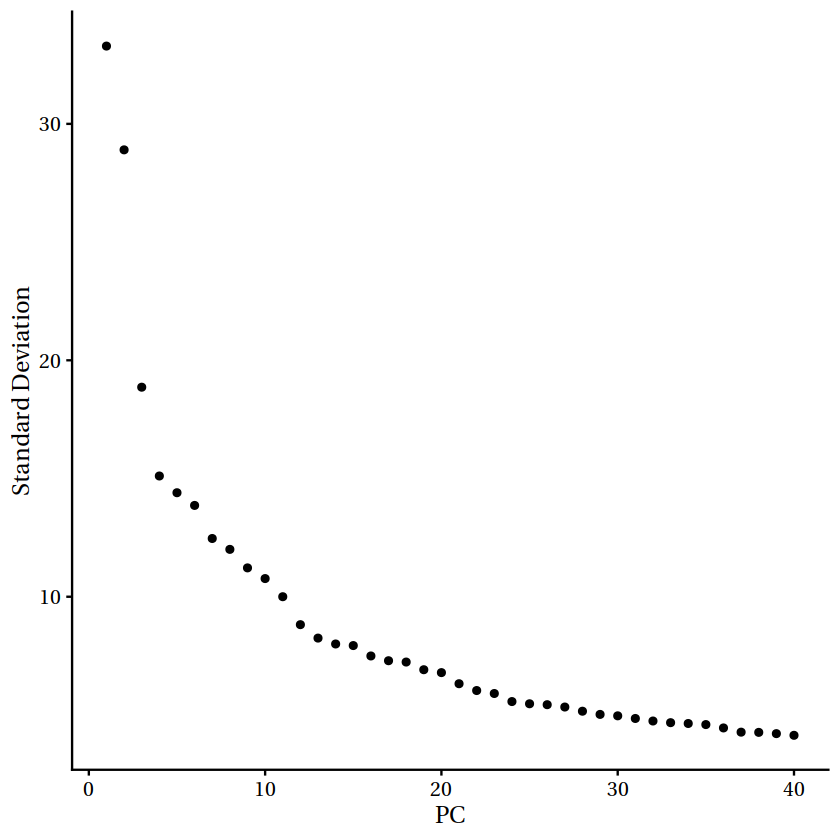

In [20]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

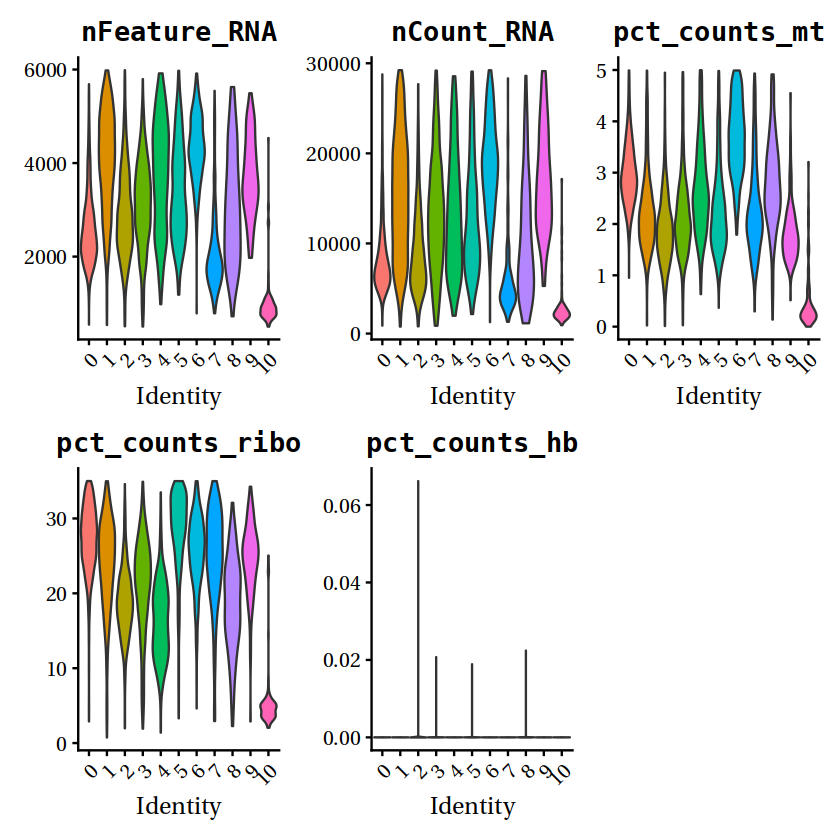

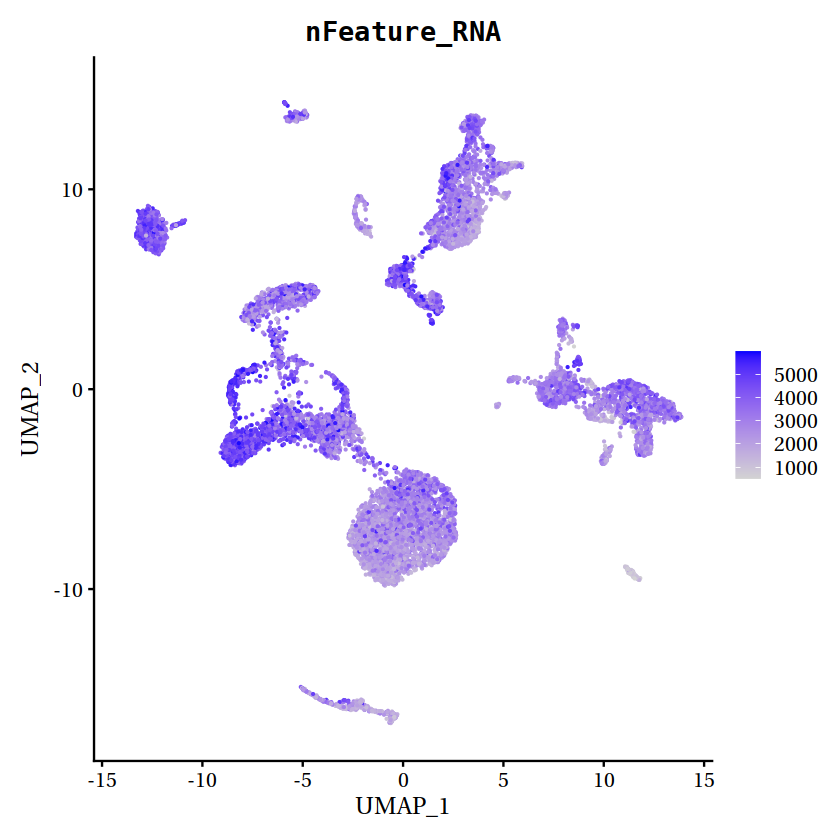

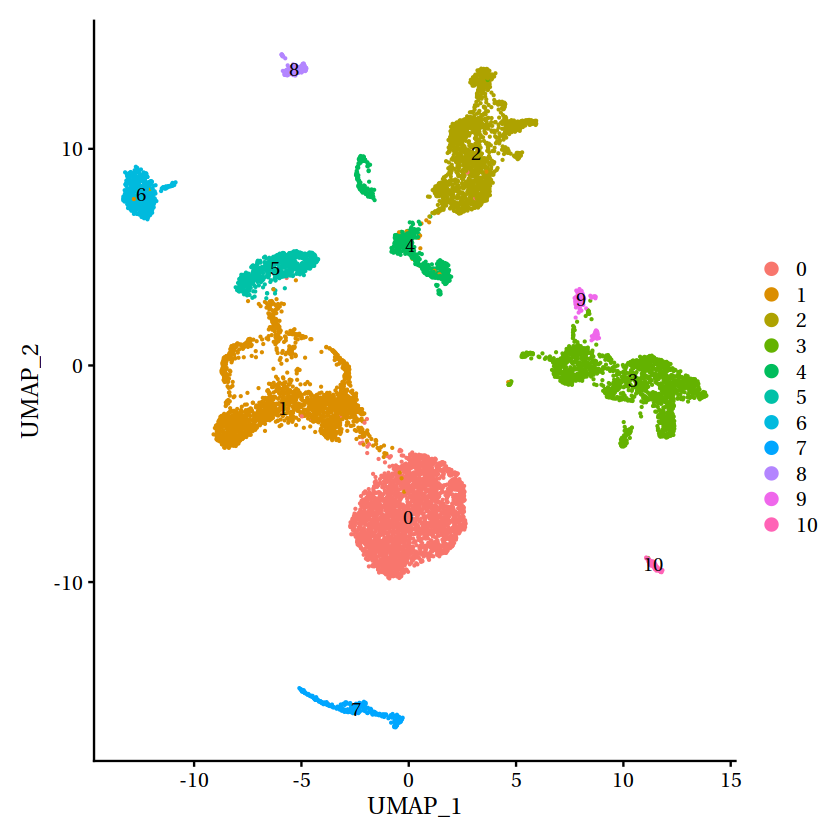

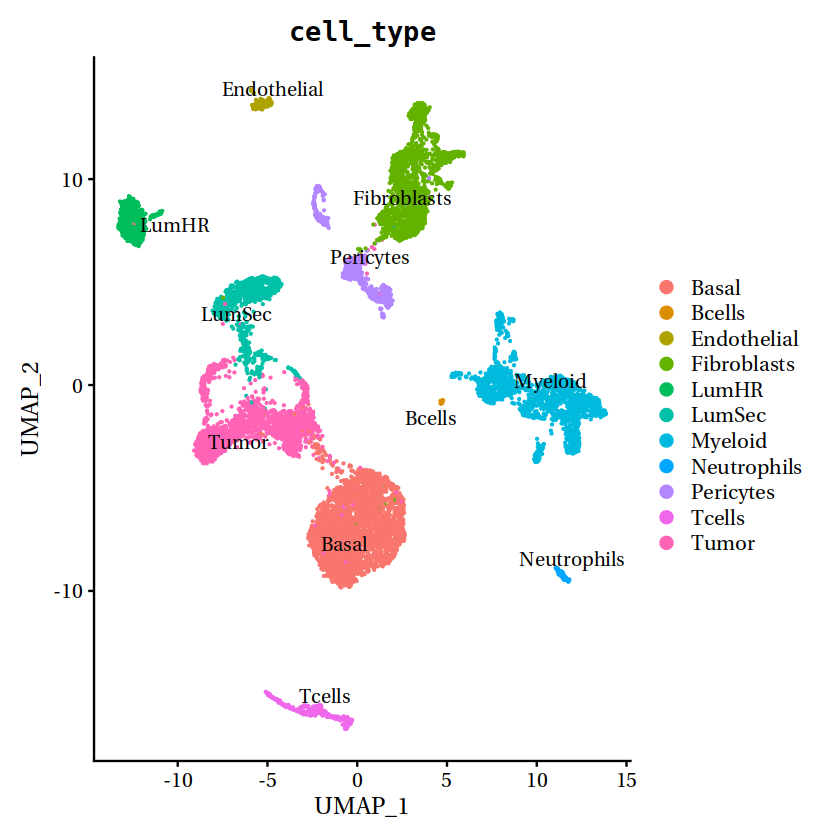

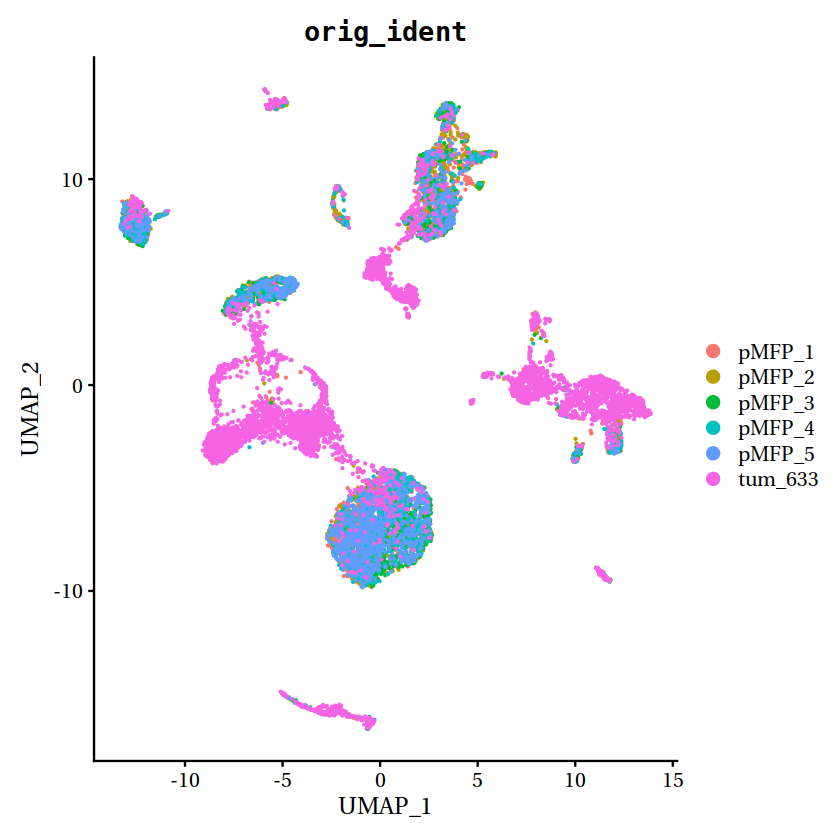

In [21]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

In [22]:
Idents(obj) <- "cell_type"
obj <- subset(obj, subset = nFeature_RNA > 1000, WhichCells(obj, ident = c("Neutrophils")), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 3000, WhichCells(obj, ident = c("Tcells")), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4000, WhichCells(obj, ident = c("Basal")), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4750, WhichCells(obj, ident = c("Fibroblasts","Myeloid")), invert = TRUE)

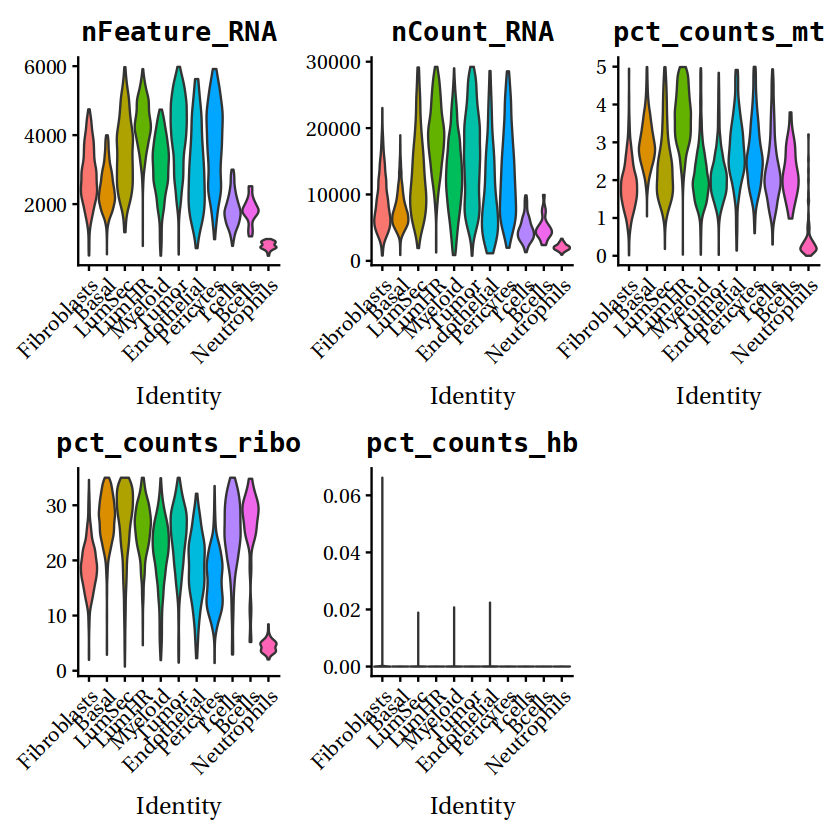

In [23]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

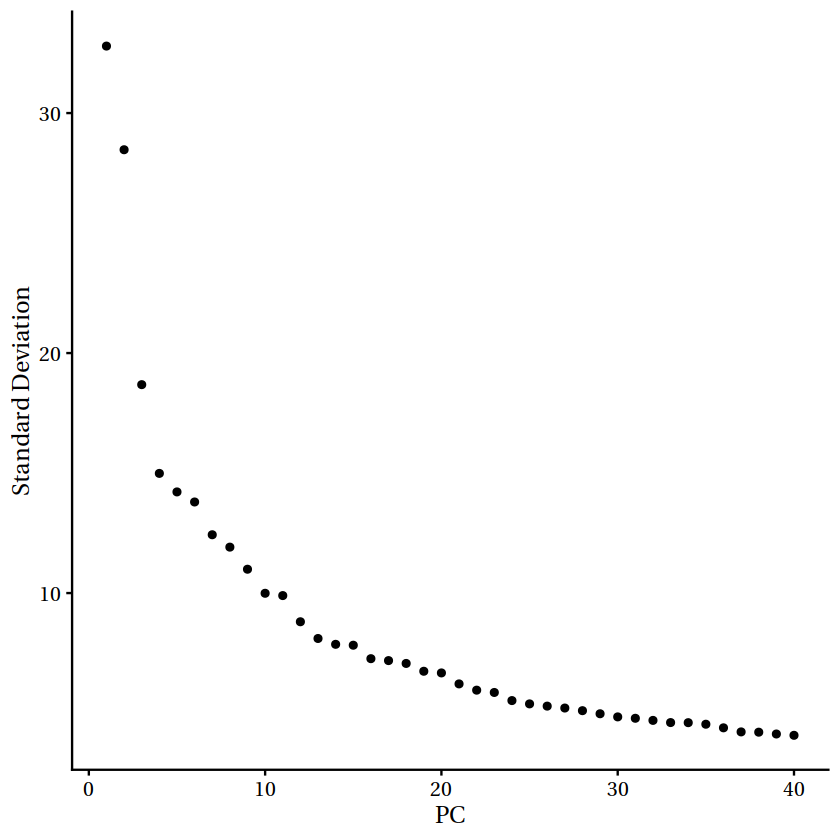

In [24]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

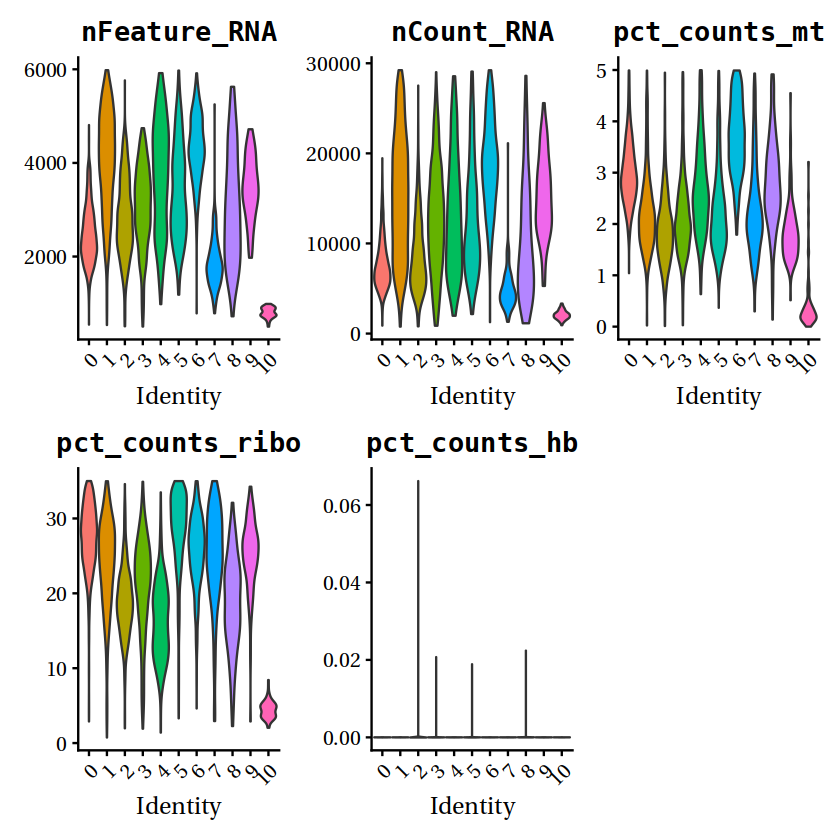

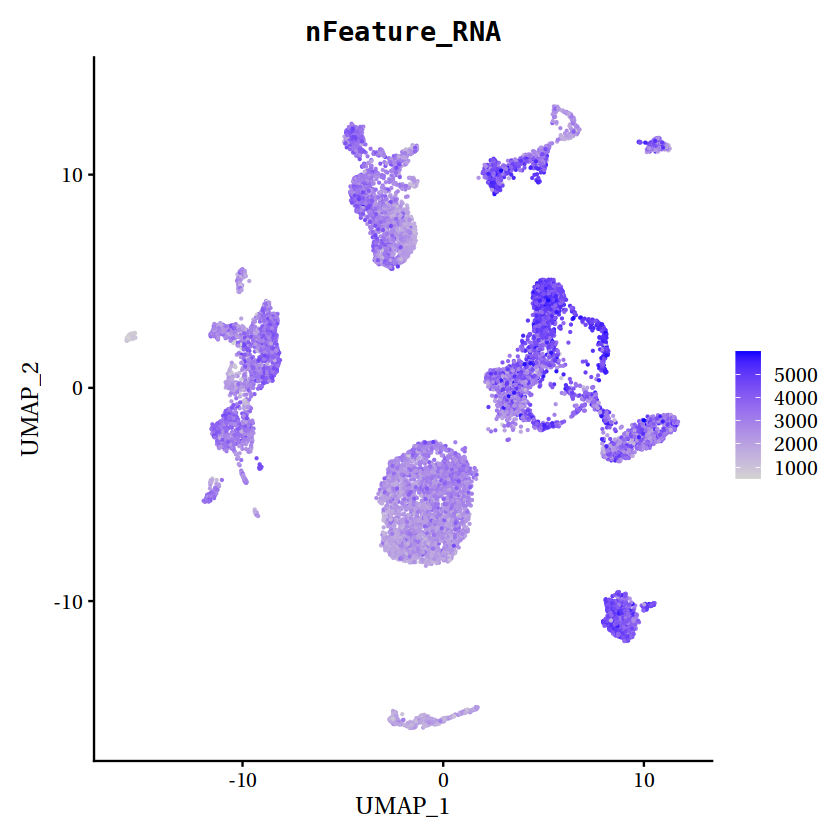

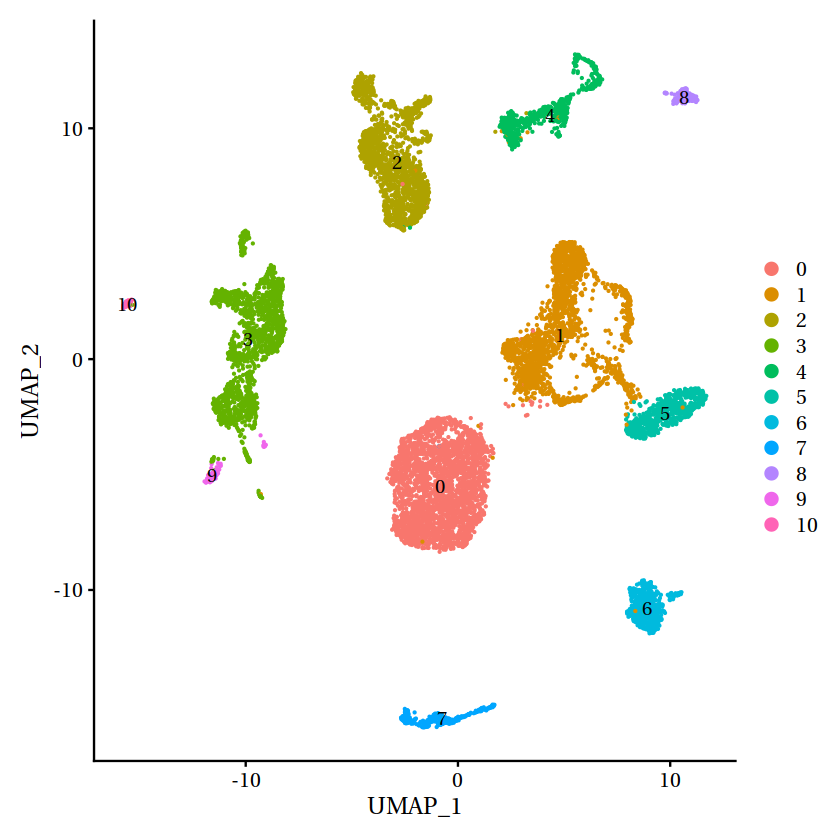

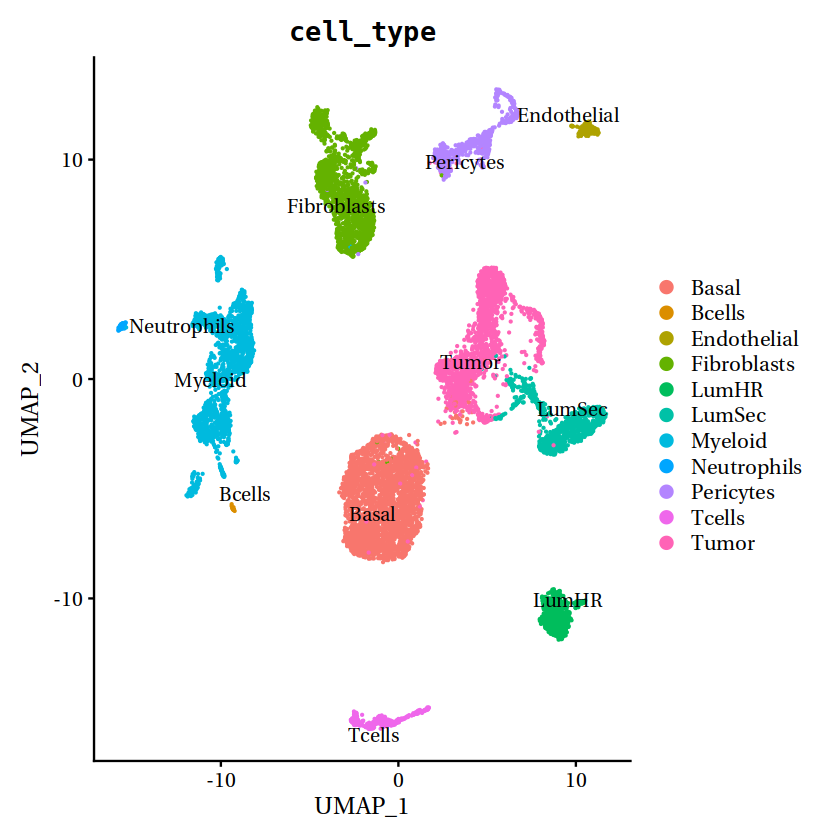

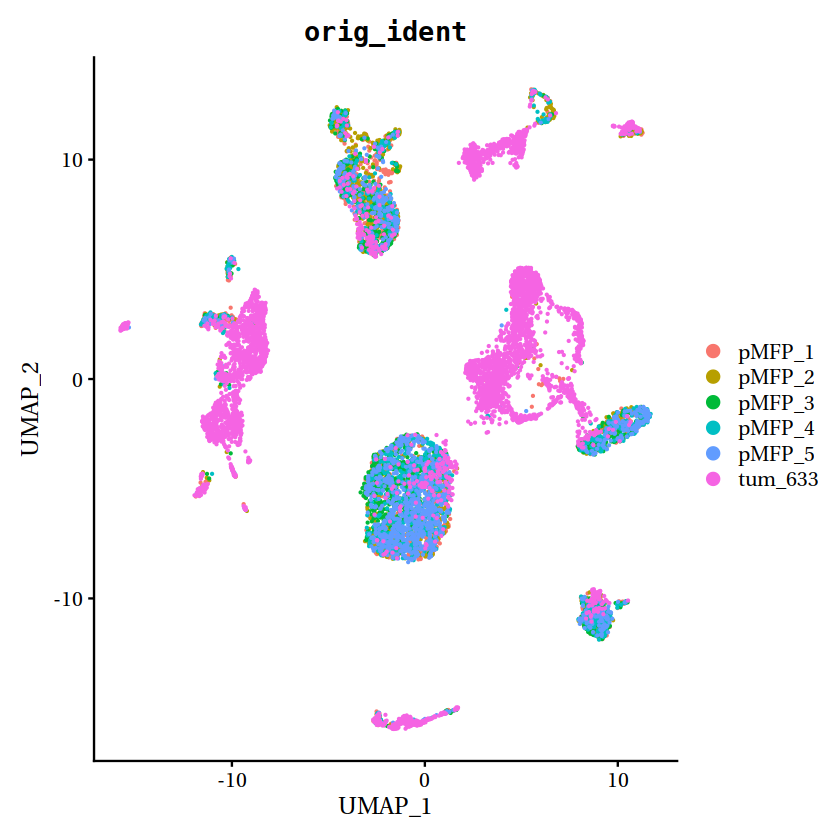

In [25]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

In [26]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA > 3000, WhichCells(obj, ident = 7), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4750, WhichCells(obj, ident = 2), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 2500, WhichCells(obj, ident = 6), invert = TRUE)

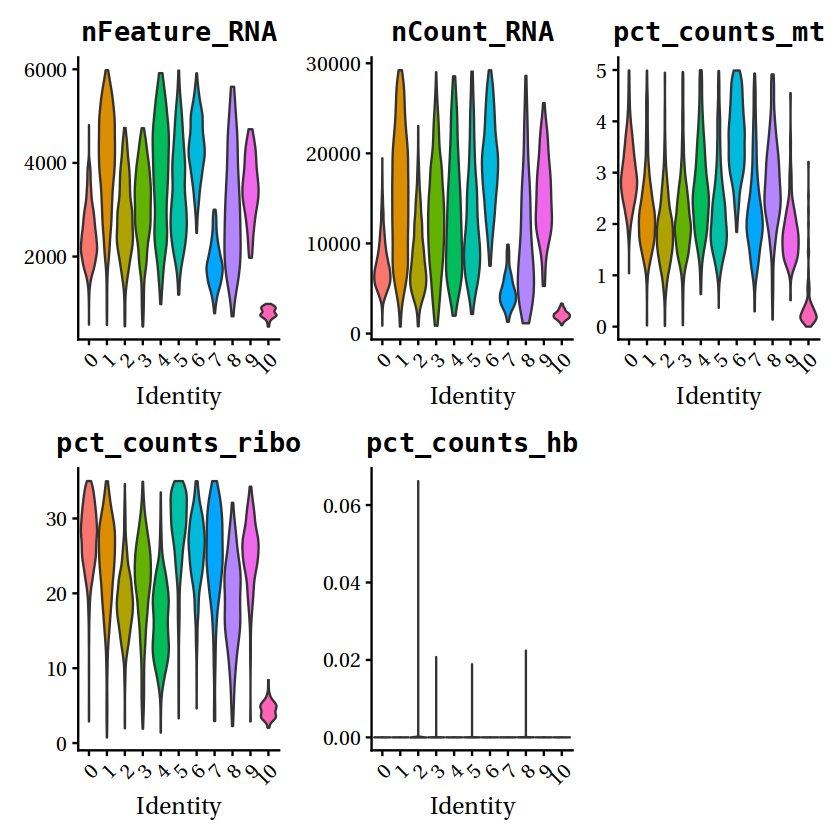

In [27]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

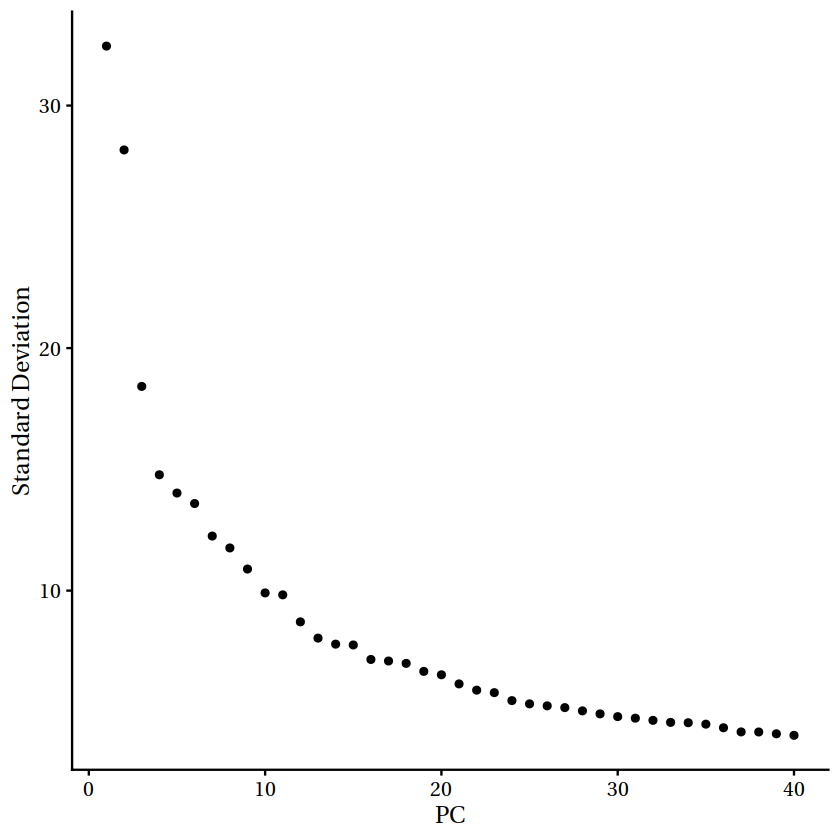

In [28]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

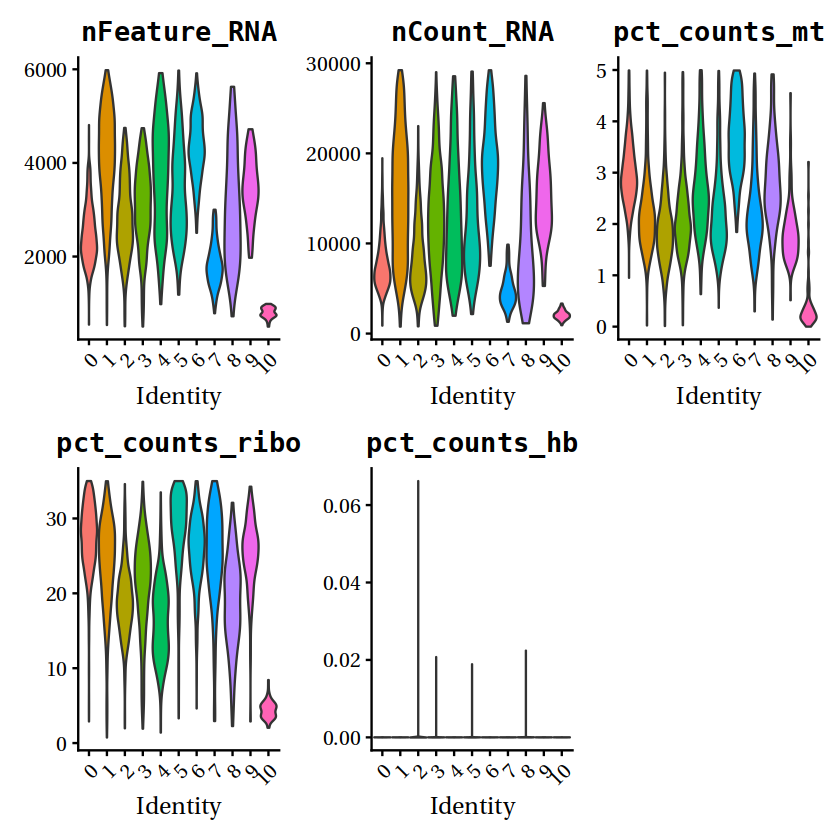

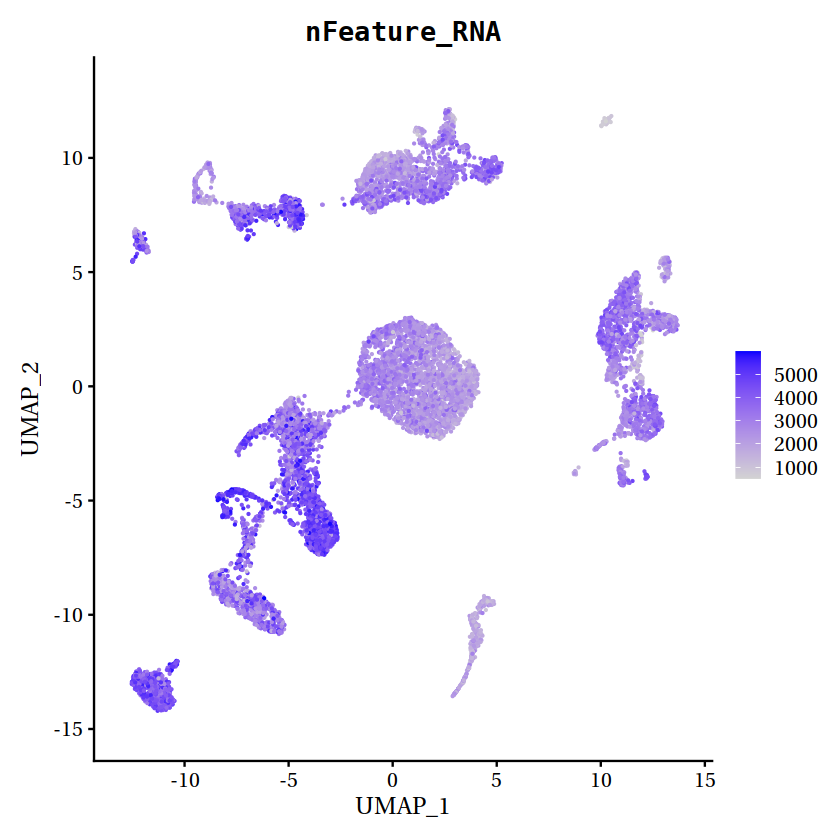

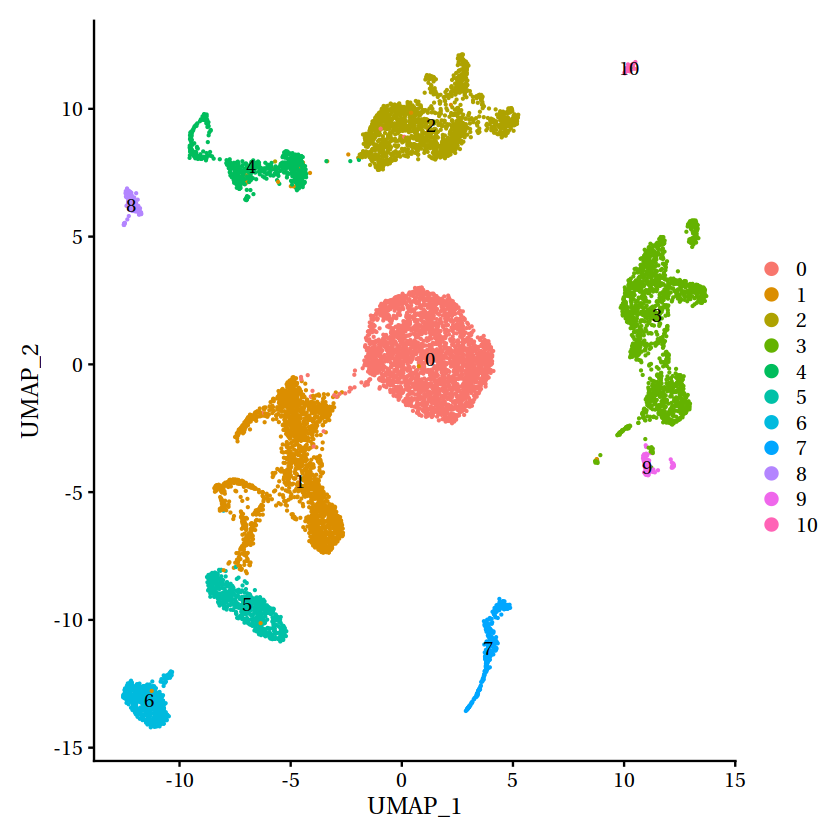

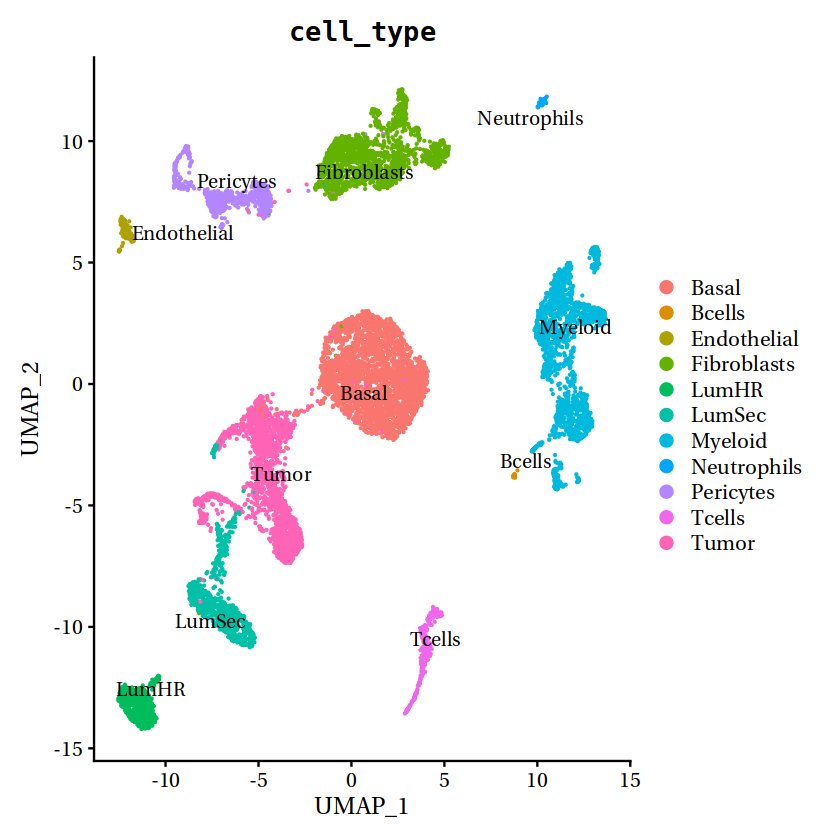

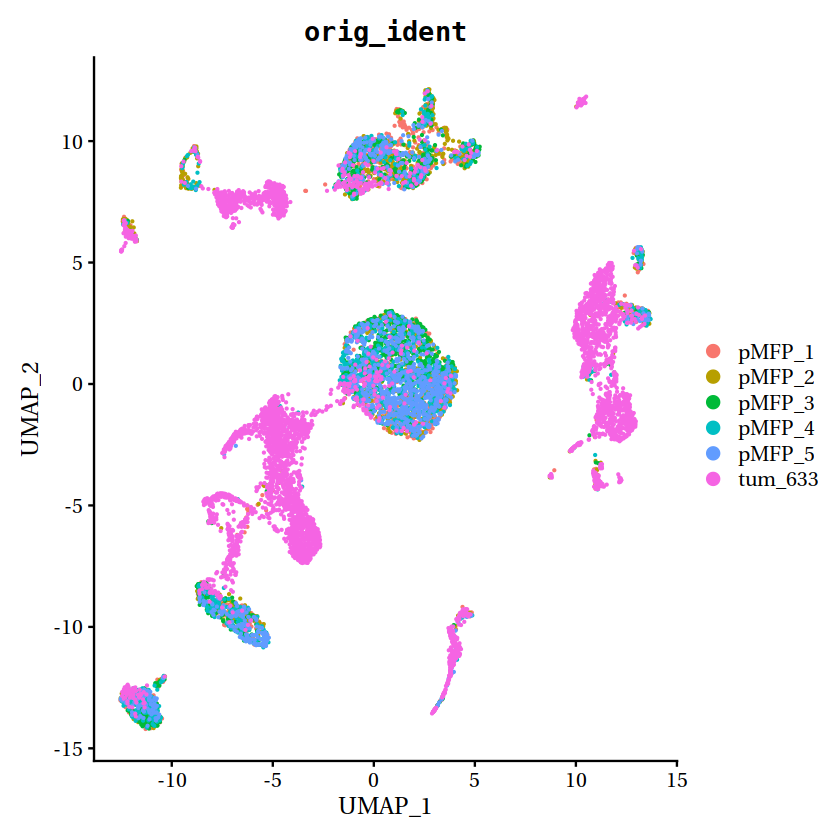

In [30]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

In [31]:
saveRDS(obj, "cellplex2_soupX.rds")

# Redocheck individual after redoing everything
### after doublet prediction 

In [2]:
obj <- readRDS("cellplex2_soupX_doubletfinder_cnv_metadata.rds")

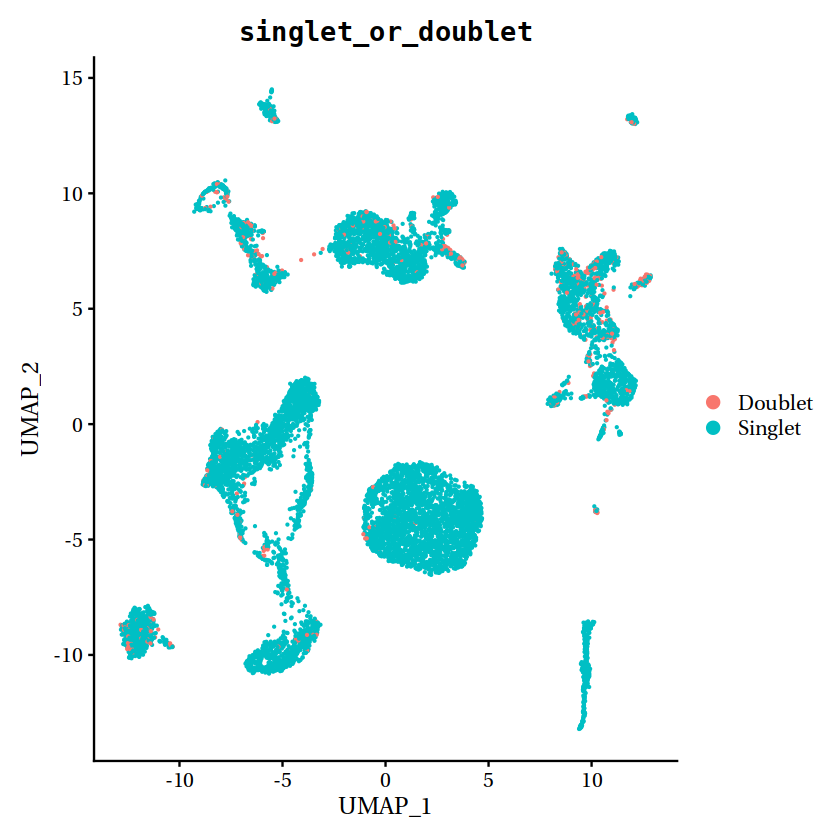

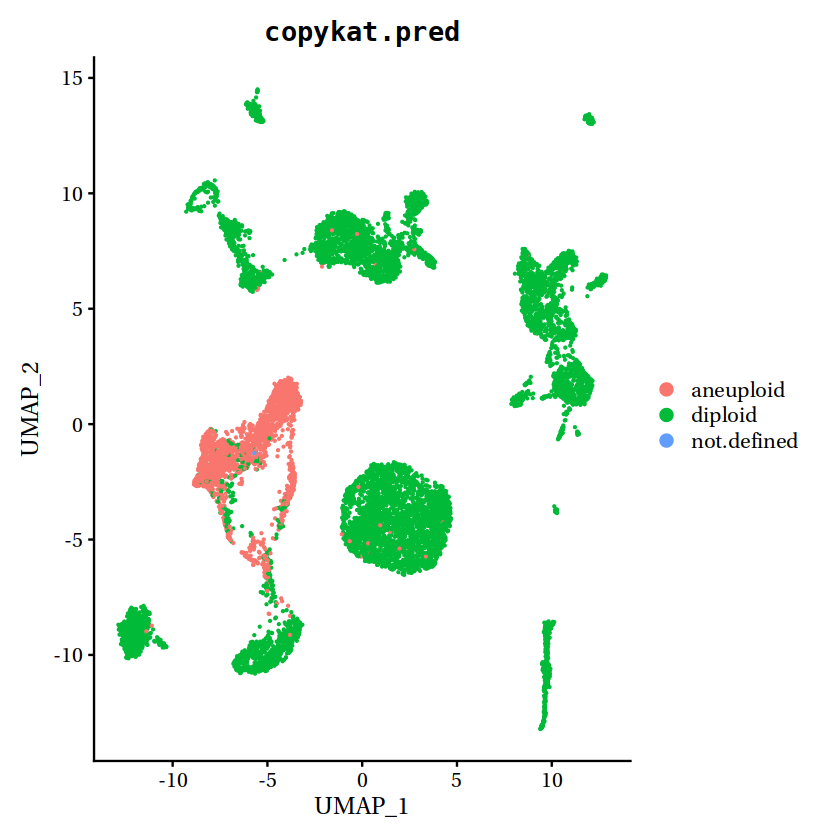

In [5]:
pred <- read.csv("cellplex_2_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

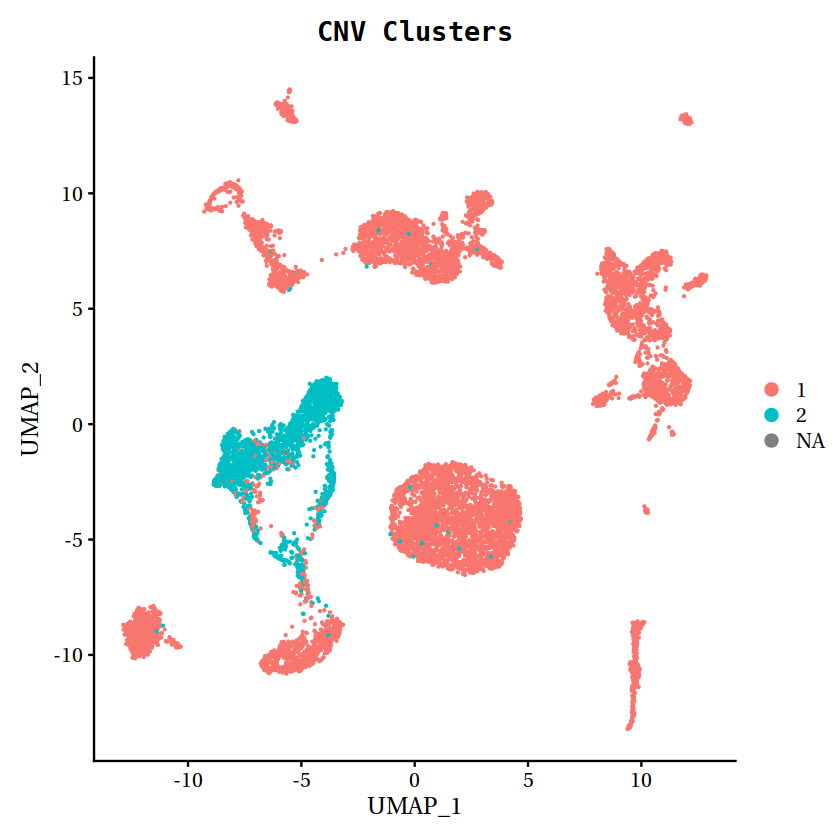

In [9]:
clust_res <- readRDS("cellplex_2_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 2, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

In [ ]:
#Original was best. Got over-written :(

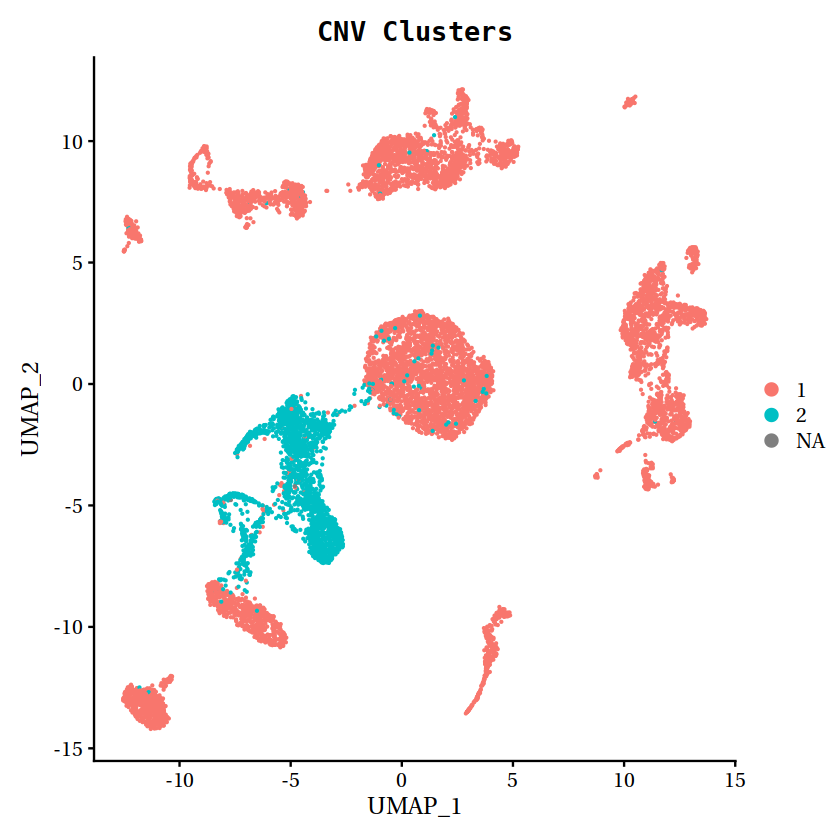

In [4]:
clust_res <- readRDS("cellplex_2_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 2, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

#### normal clean up

In [10]:
sub <- subset(obj, subset = orig_ident == "tum_633", invert = T)

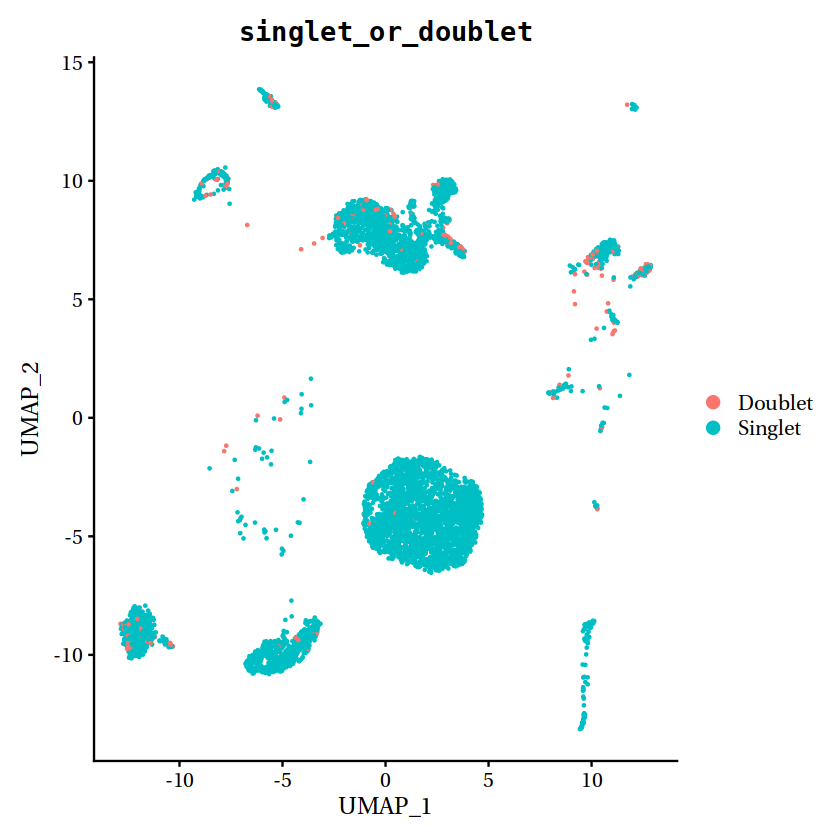

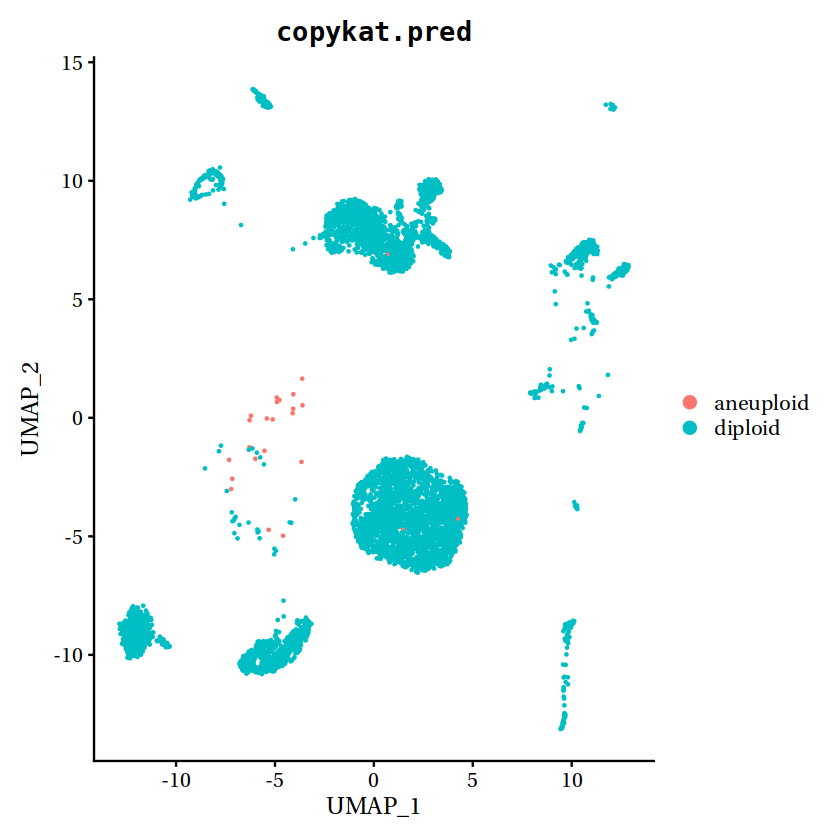

In [11]:
DimPlot(sub, group.by = "singlet_or_doublet")
DimPlot(sub, group.by="copykat.pred")

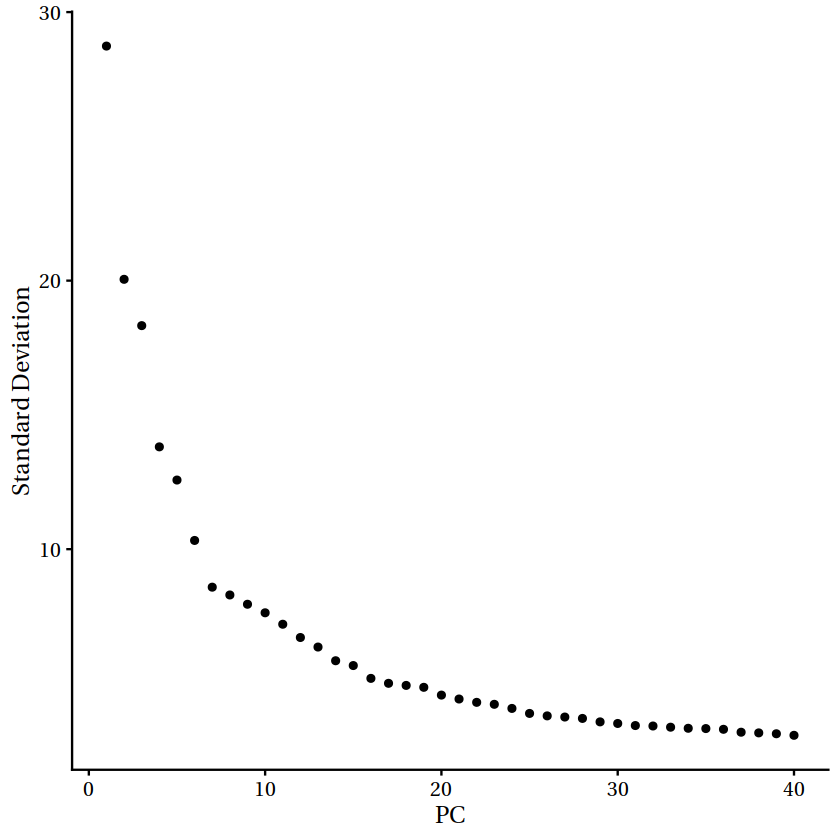

In [12]:
hvg <- read.csv("cellplex2.bigsur.hvg.csv", row.names = 1)

sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

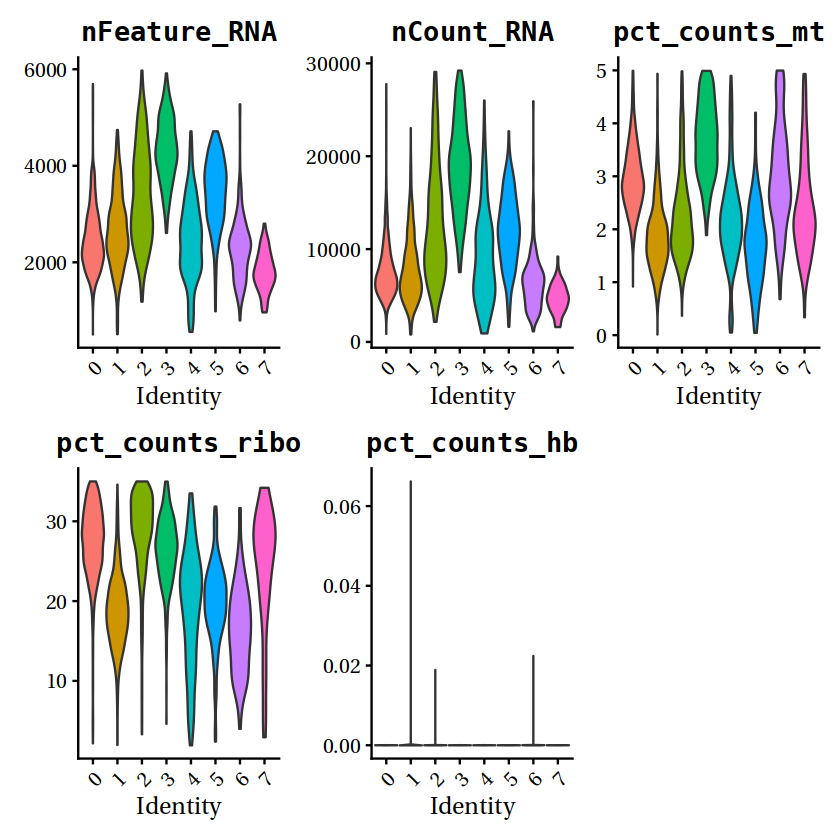

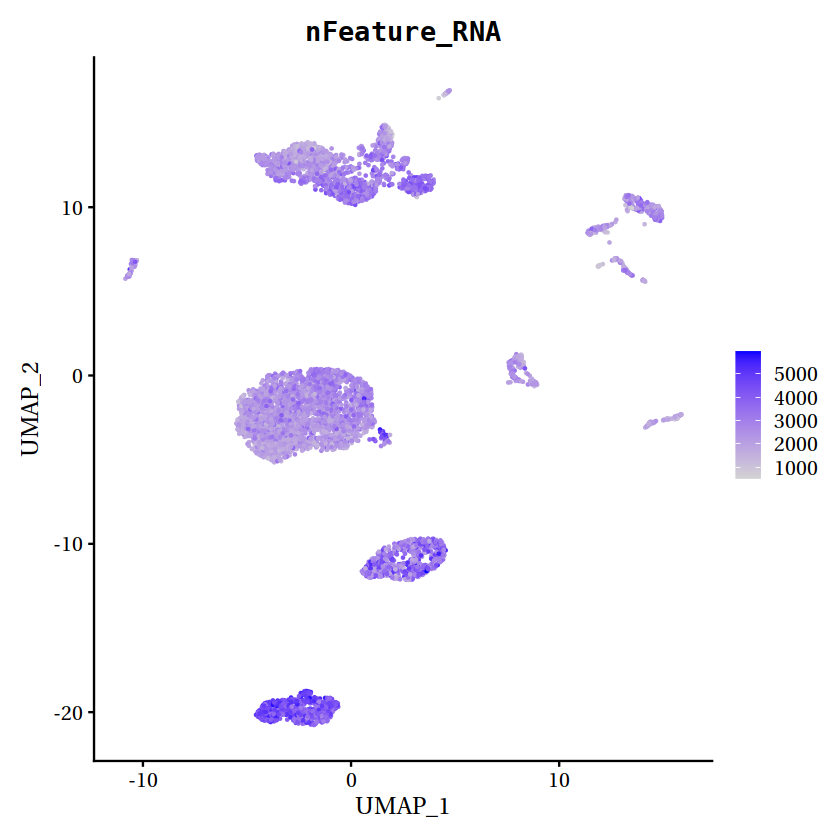

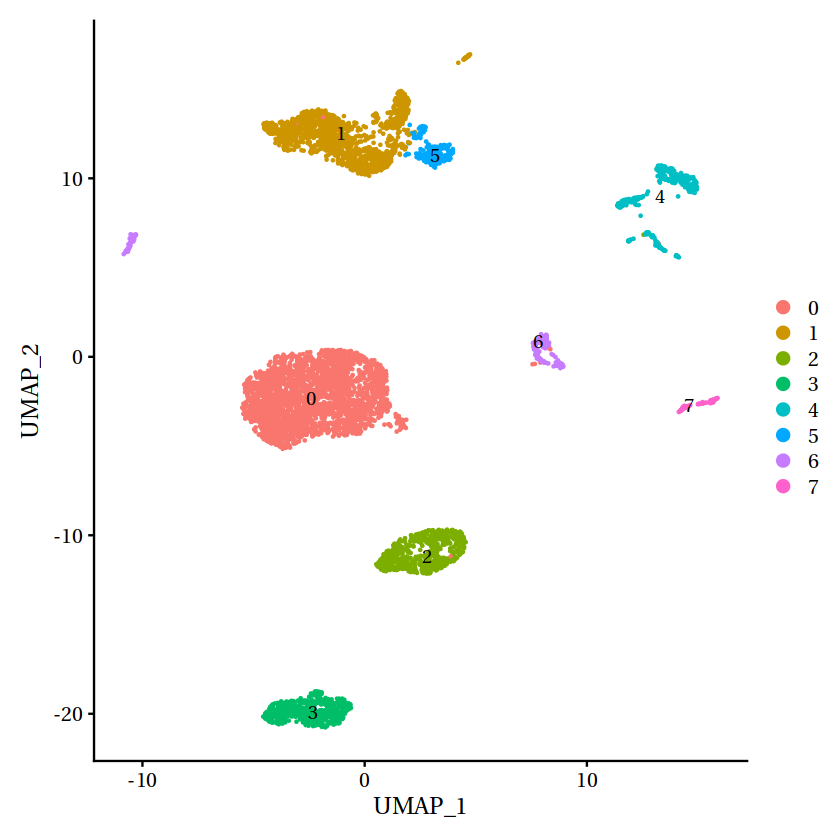

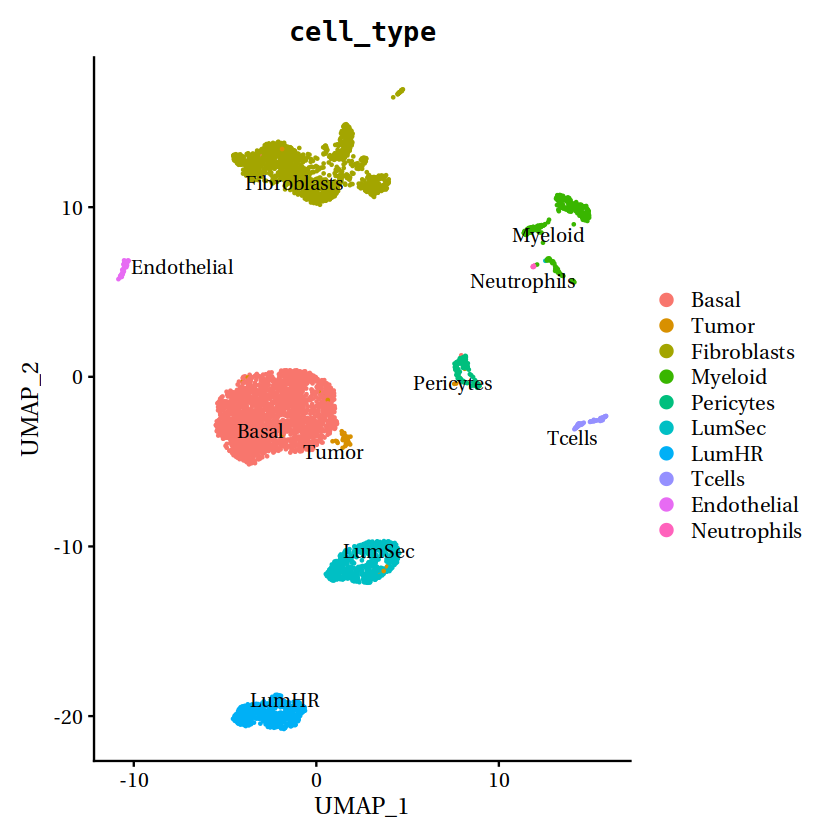

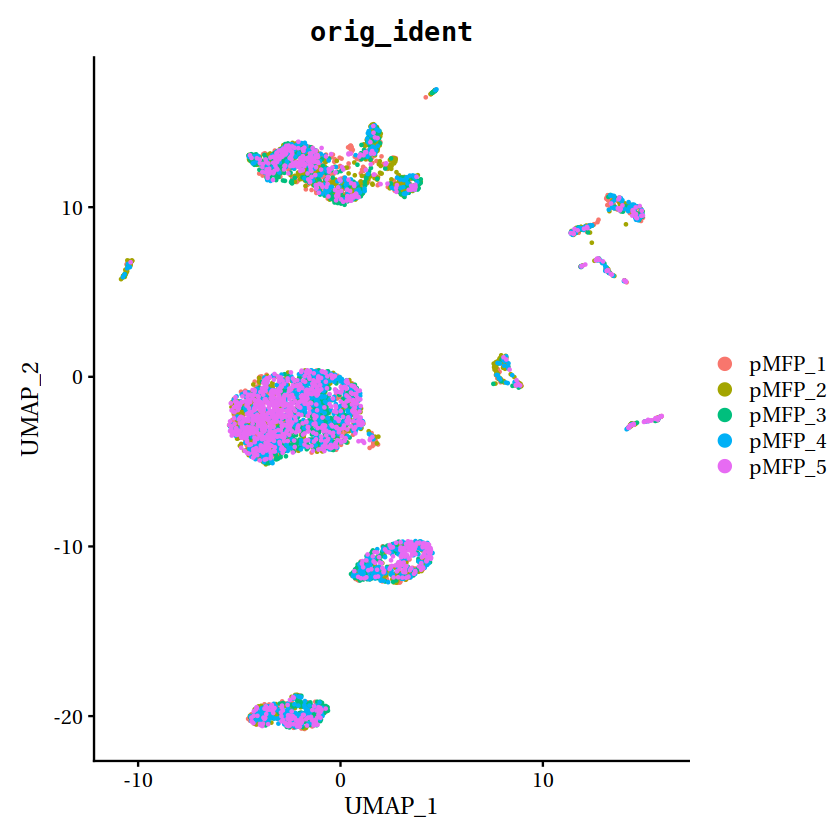

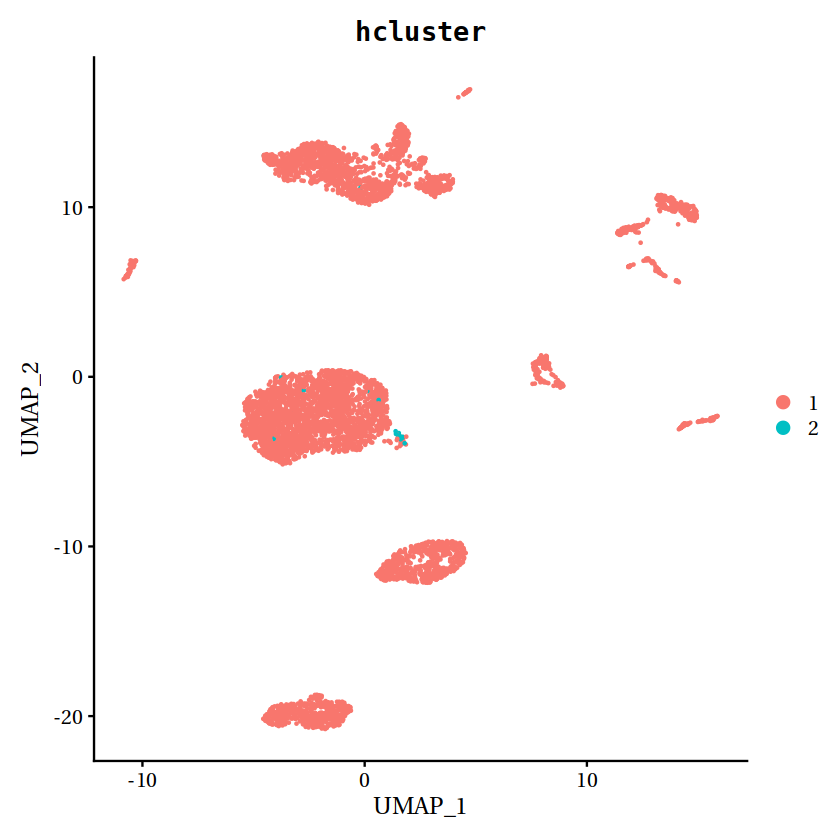

In [24]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "hcluster", label = F)

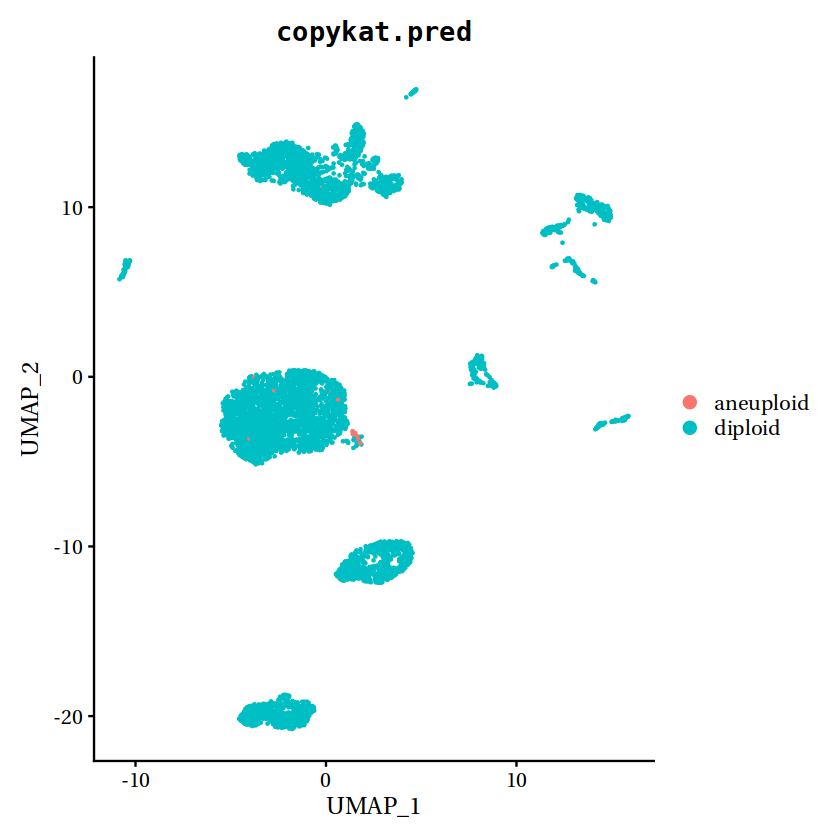

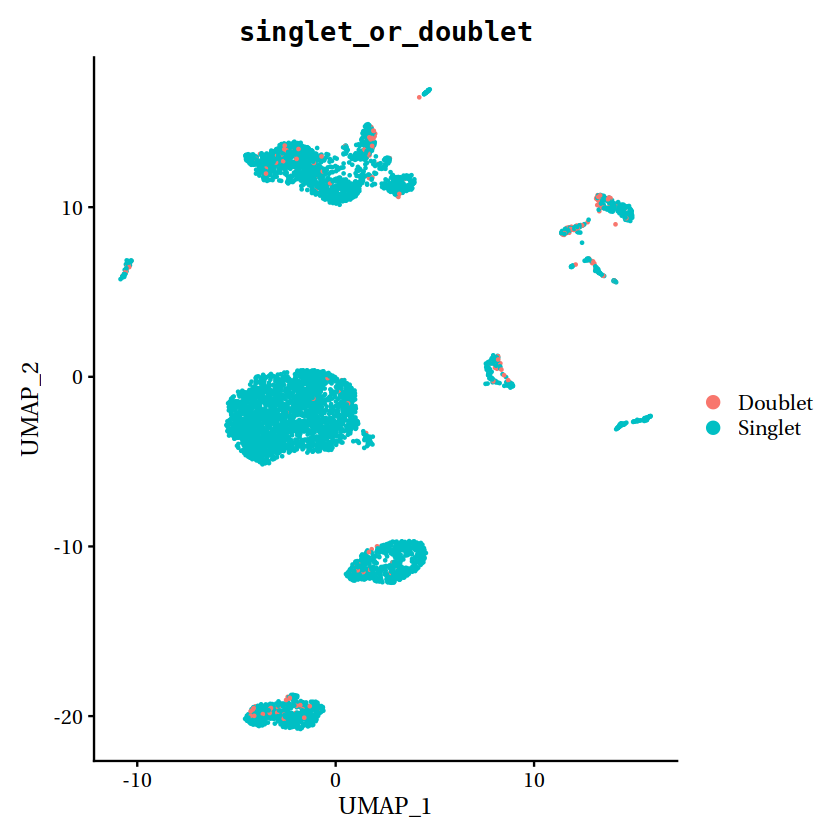

In [17]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")

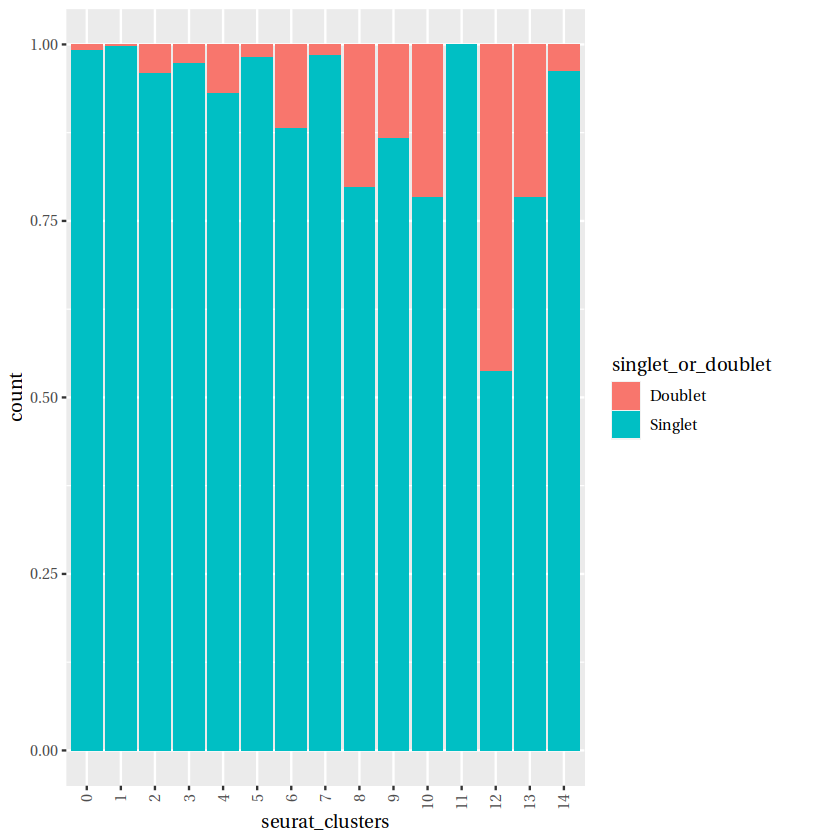

In [18]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

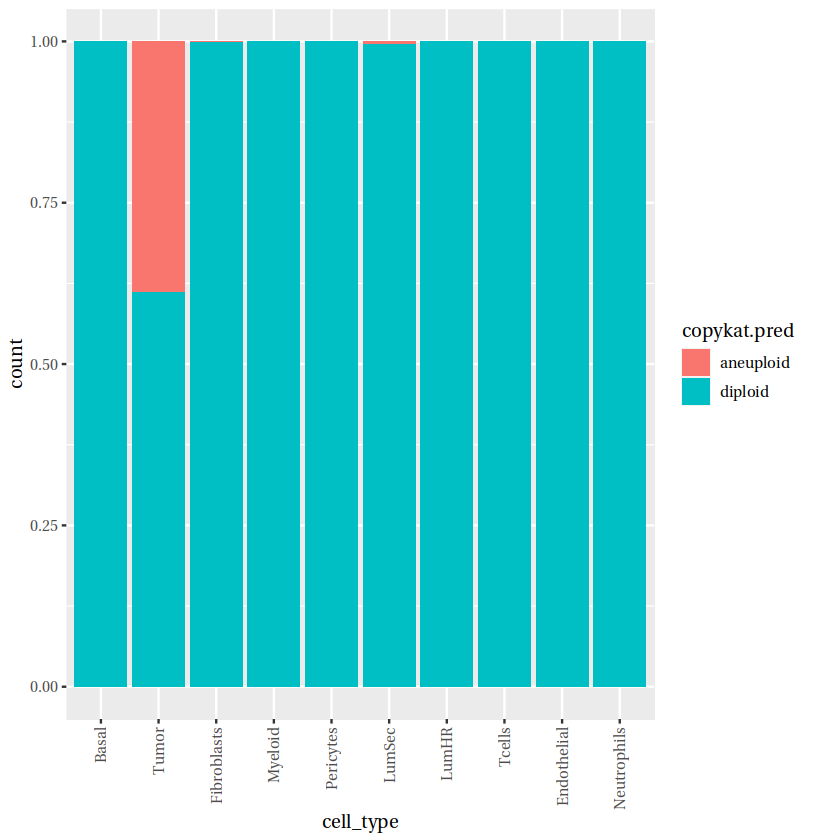

In [22]:
ggplot(sub@meta.data, aes(x=cell_type, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

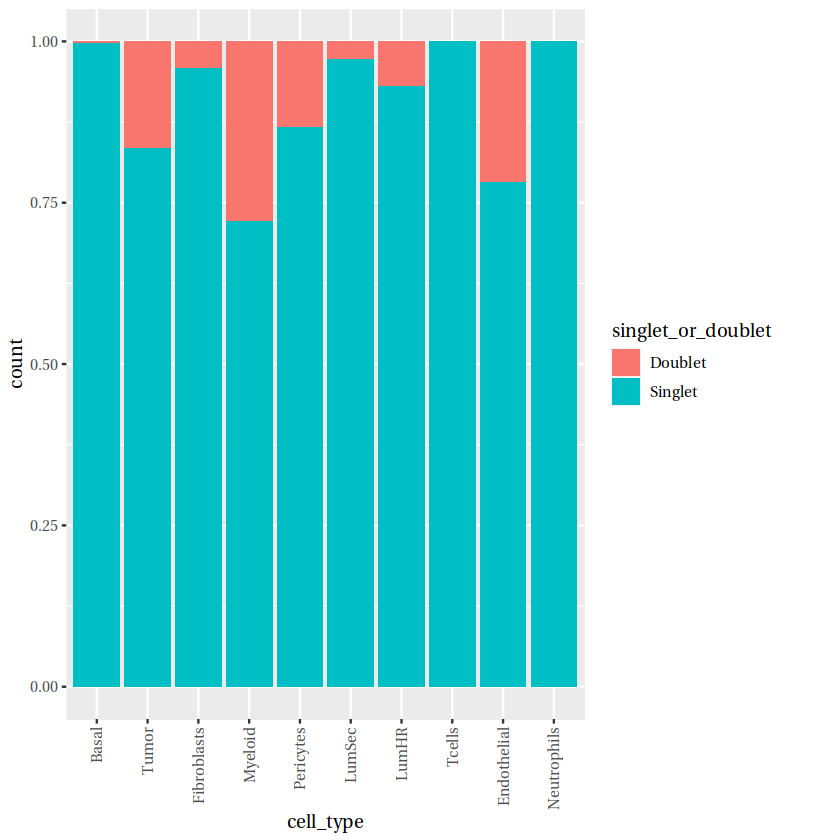

In [25]:
ggplot(sub@meta.data, aes(x=cell_type, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

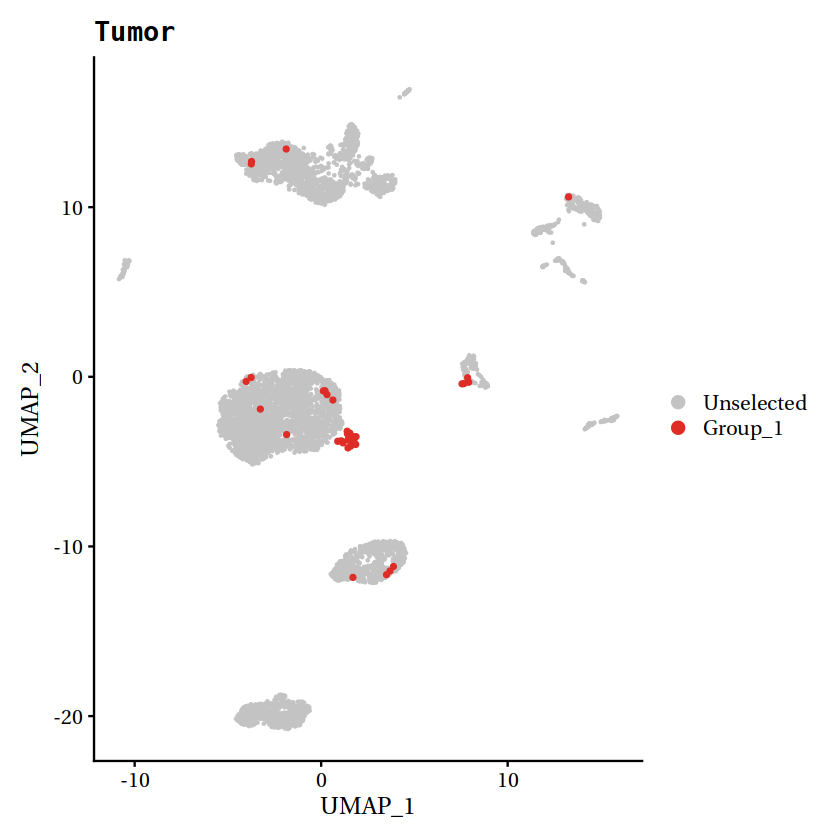

In [19]:
Idents(sub) <- "cell_type"
DimPlot(sub, cells.highlight = WhichCells(sub, ident = c("Tumor")))+ggtitle("Tumor")

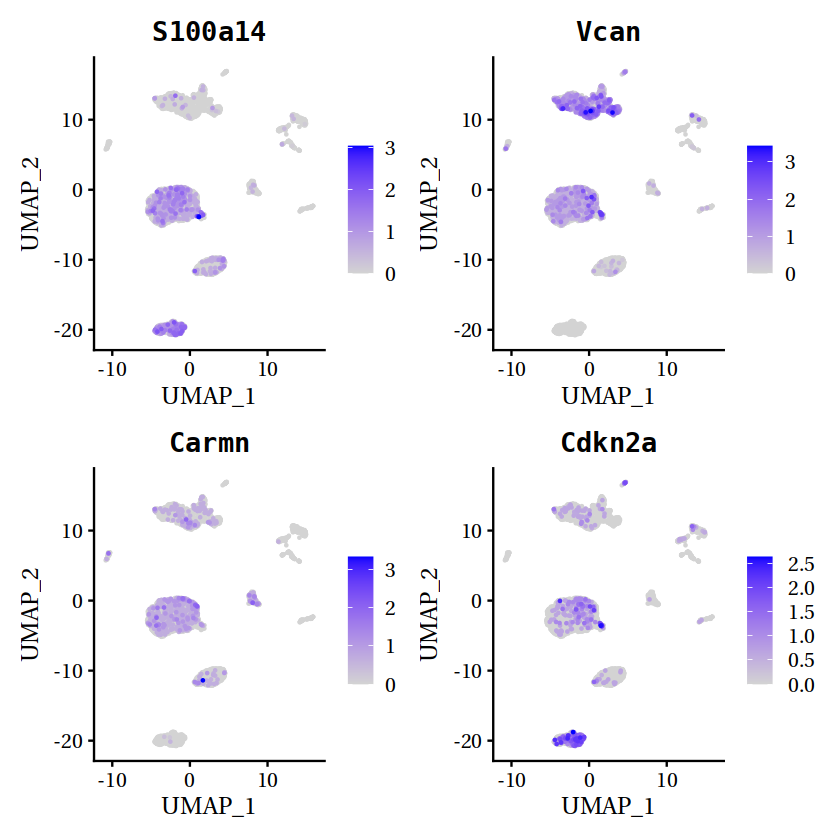

In [26]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)

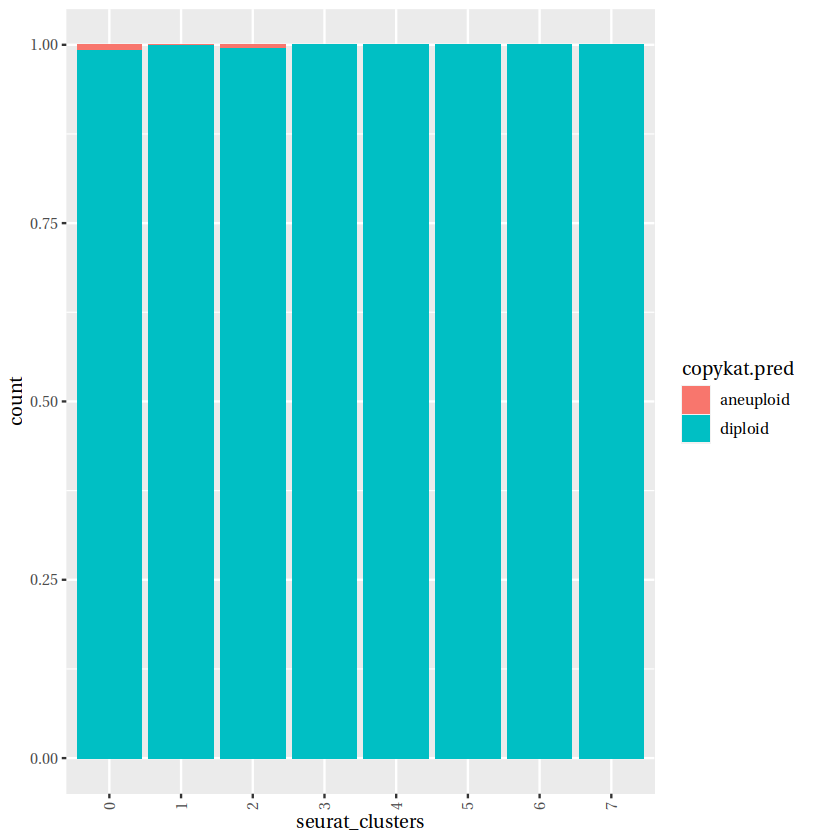

In [27]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check but don't save tumor 633

In [28]:
sub <- subset(obj, subset = orig_ident == "tum_633")

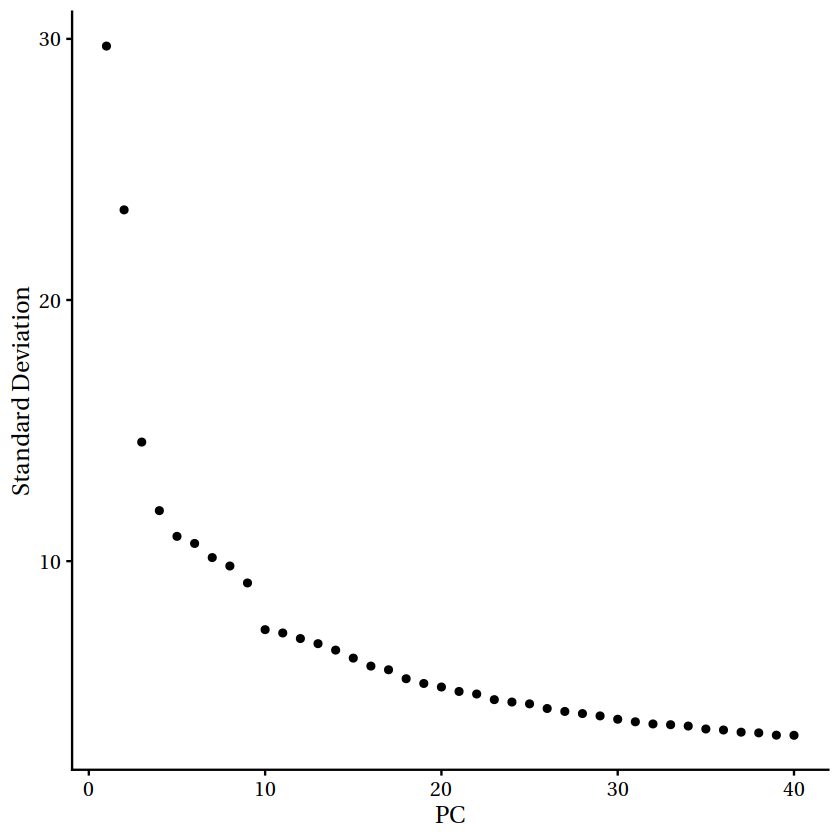

In [29]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

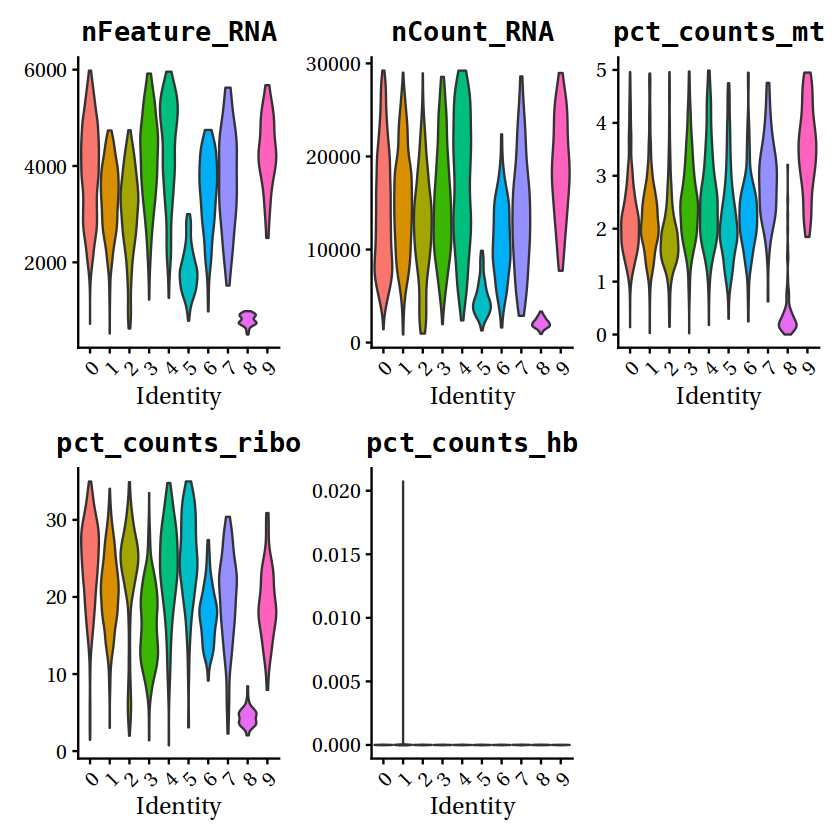

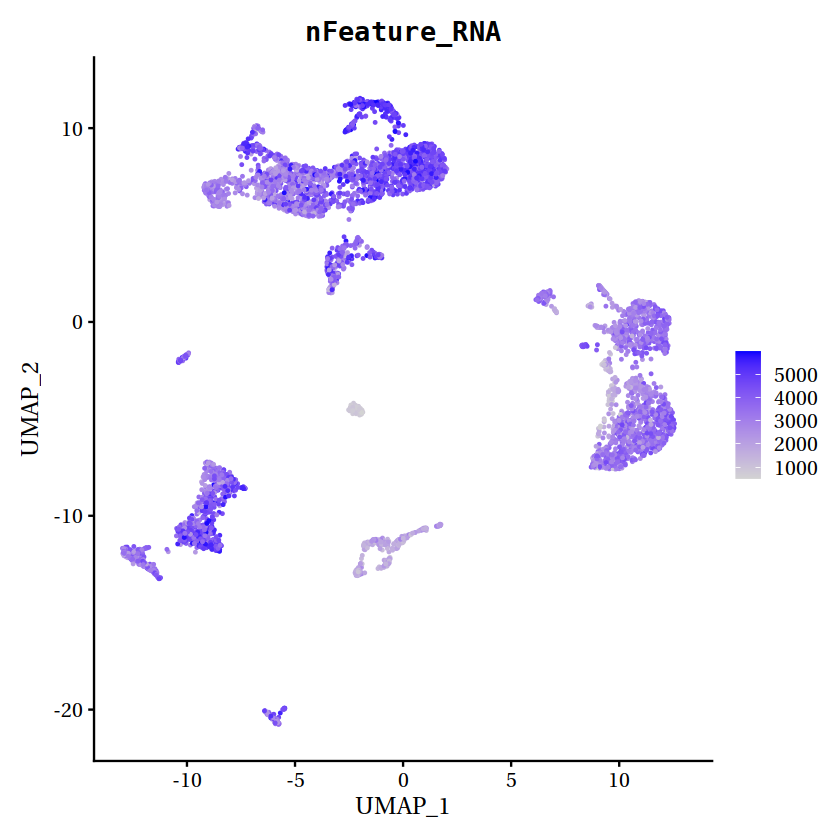

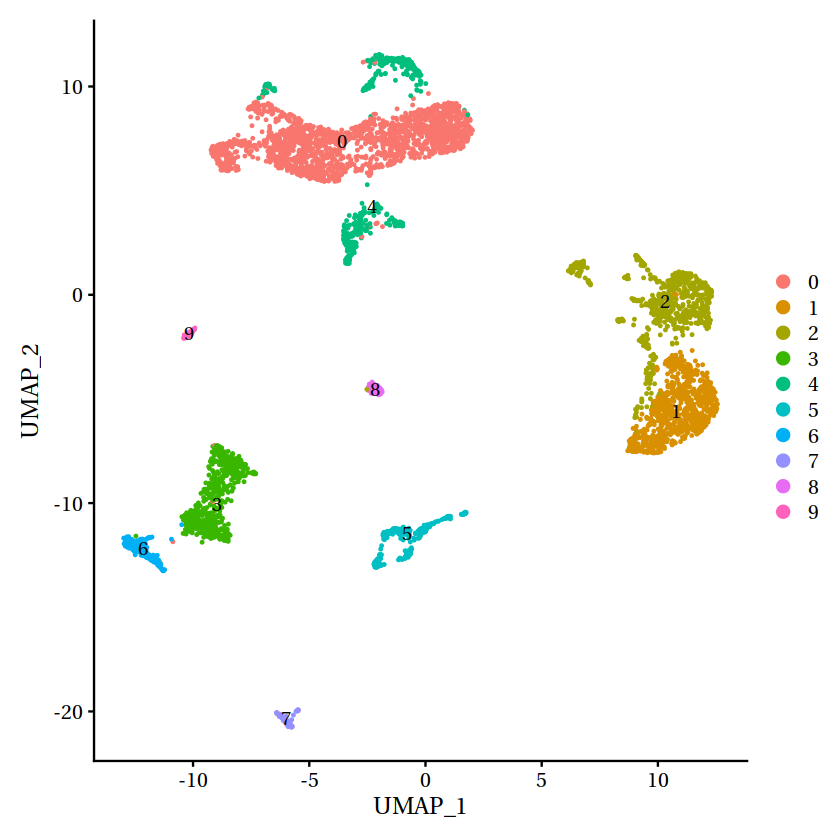

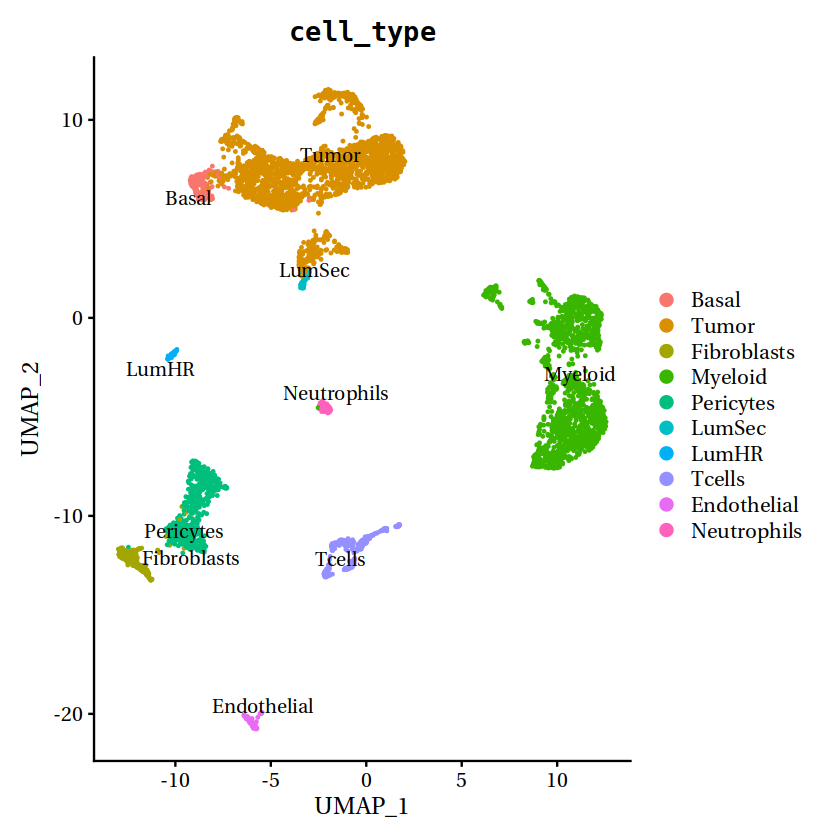

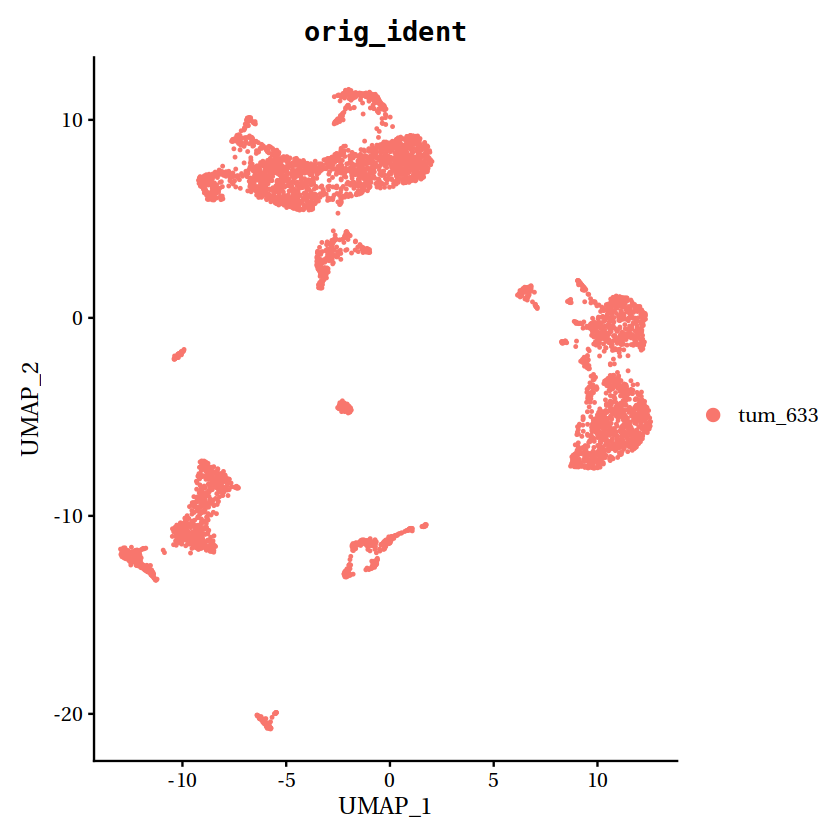

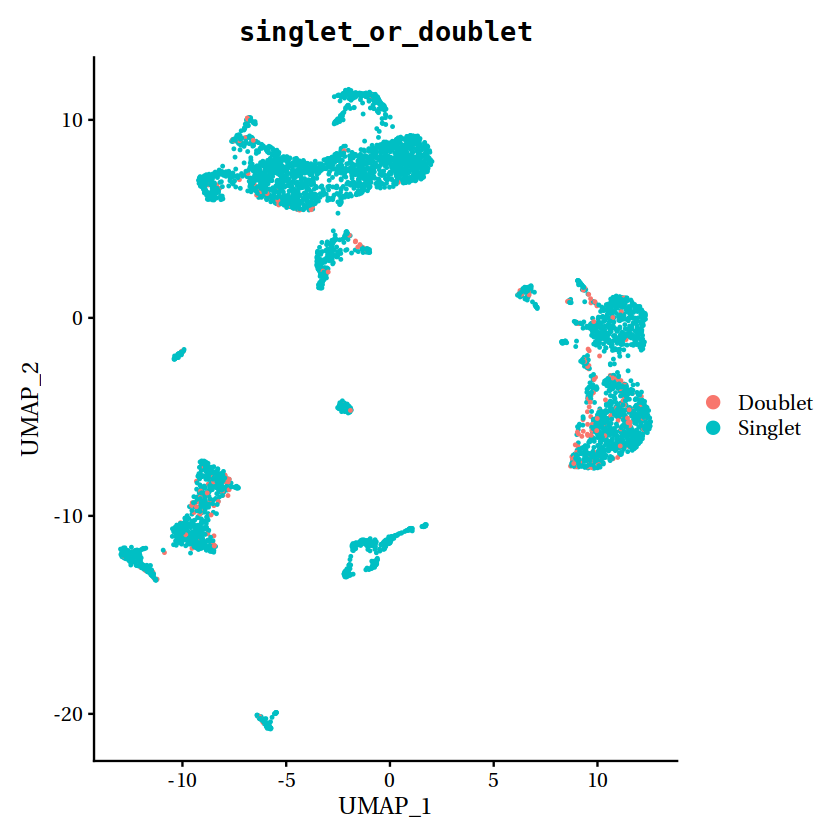

In [30]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

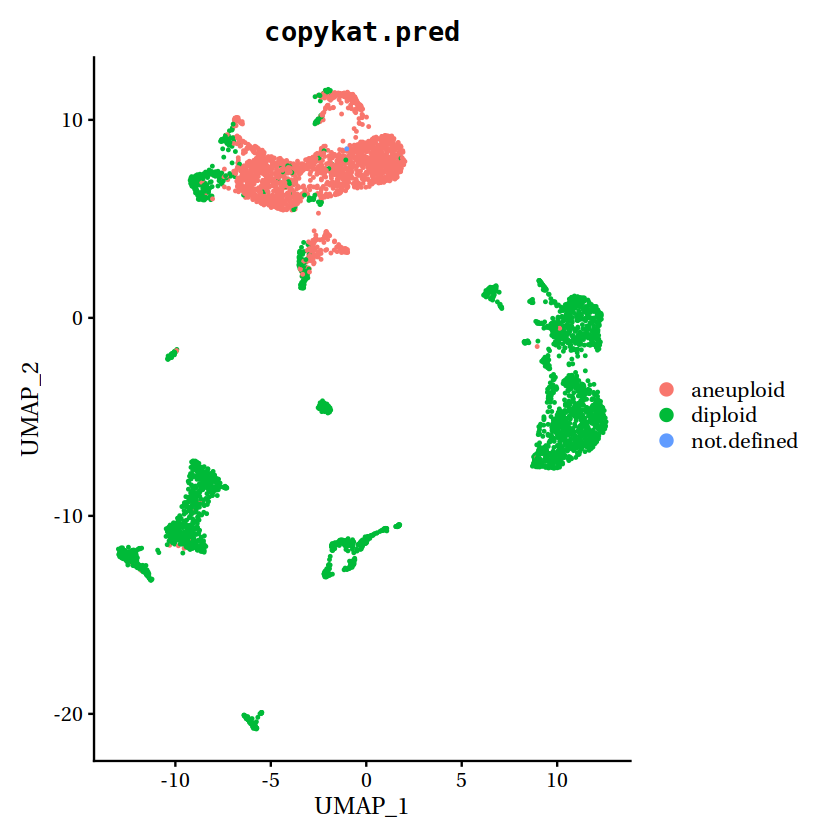

In [31]:
DimPlot(sub, group.by="copykat.pred")

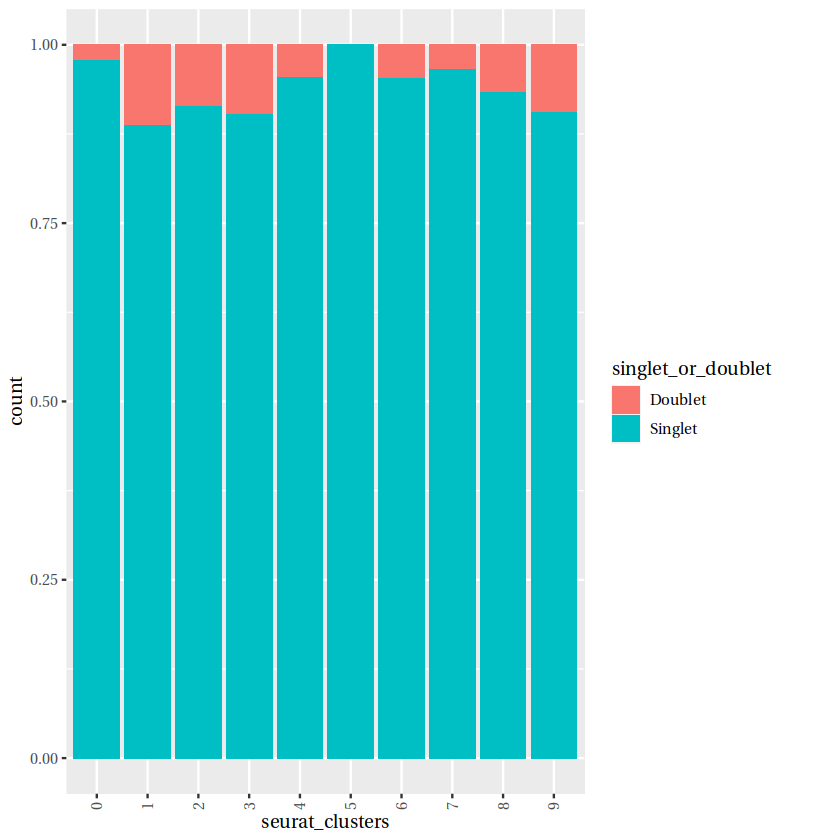

In [32]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

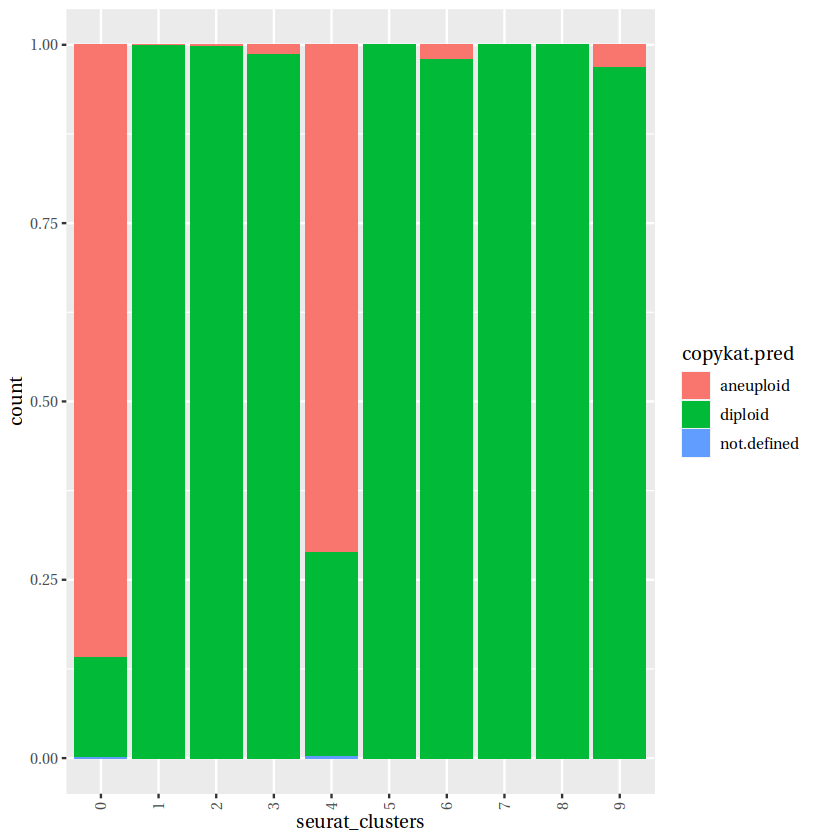

In [33]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

## clean up (remove tails)

In [6]:
### loaded earlier

In [7]:
Idents(obj) <- "seurat_clusters"

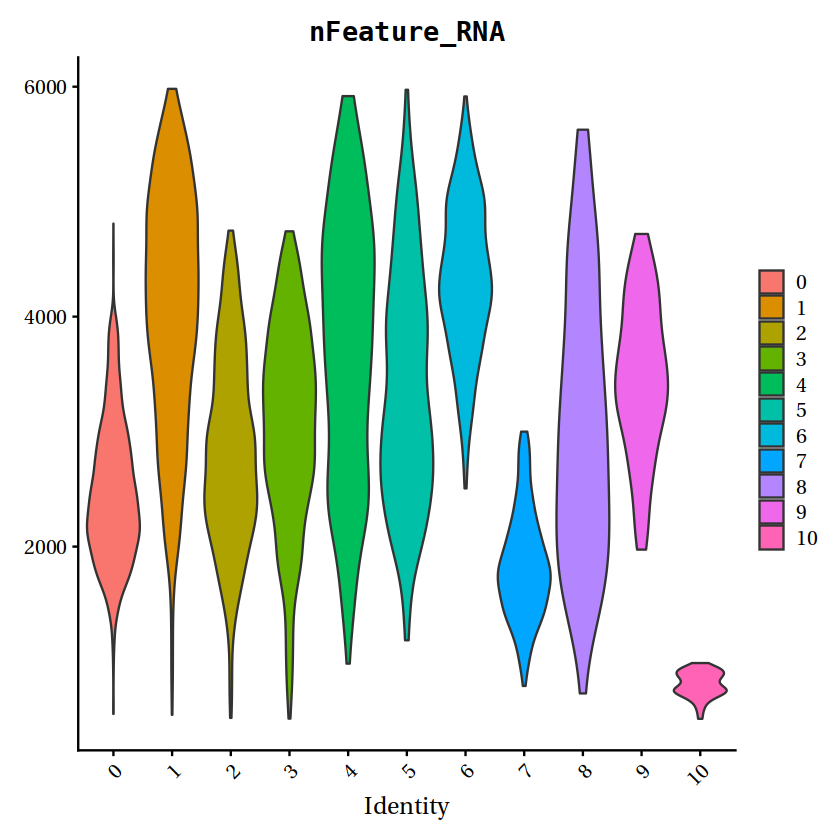

In [8]:
VlnPlot(obj, "nFeature_RNA", pt.size = 0)

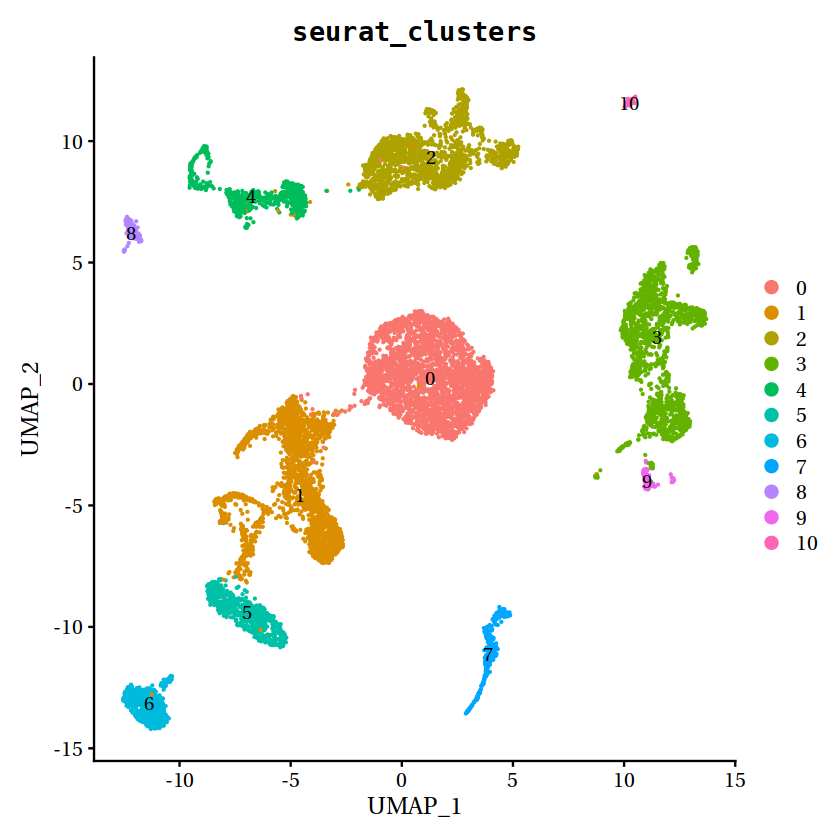

In [8]:
DimPlot(obj, group.by = "seurat_clusters", label = T)

In [9]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA > 4000, WhichCells(obj, ident = 0), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 1000, WhichCells(obj, ident = 0), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 1500, WhichCells(obj, ident = 1), invert = TRUE)
#obj <- subset(obj, subset = nFeature_RNA < 1000, WhichCells(obj, ident = 2), invert = TRUE) 
#don't remove mesenchymal low-nfeature; could be scwann/adipo

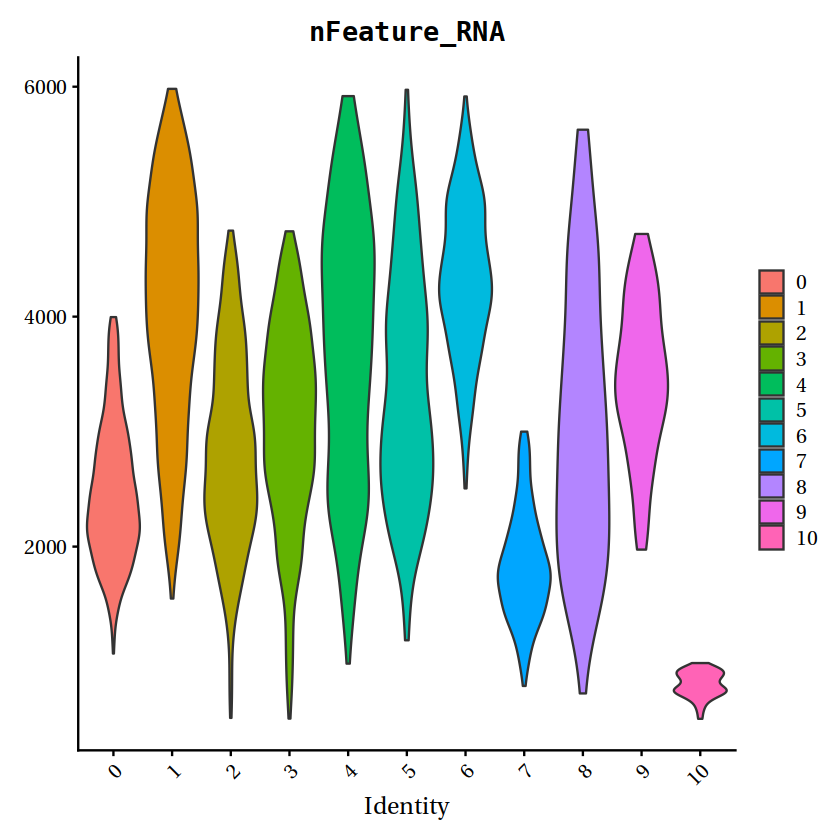

In [10]:
VlnPlot(obj, "nFeature_RNA", pt.size = 0)

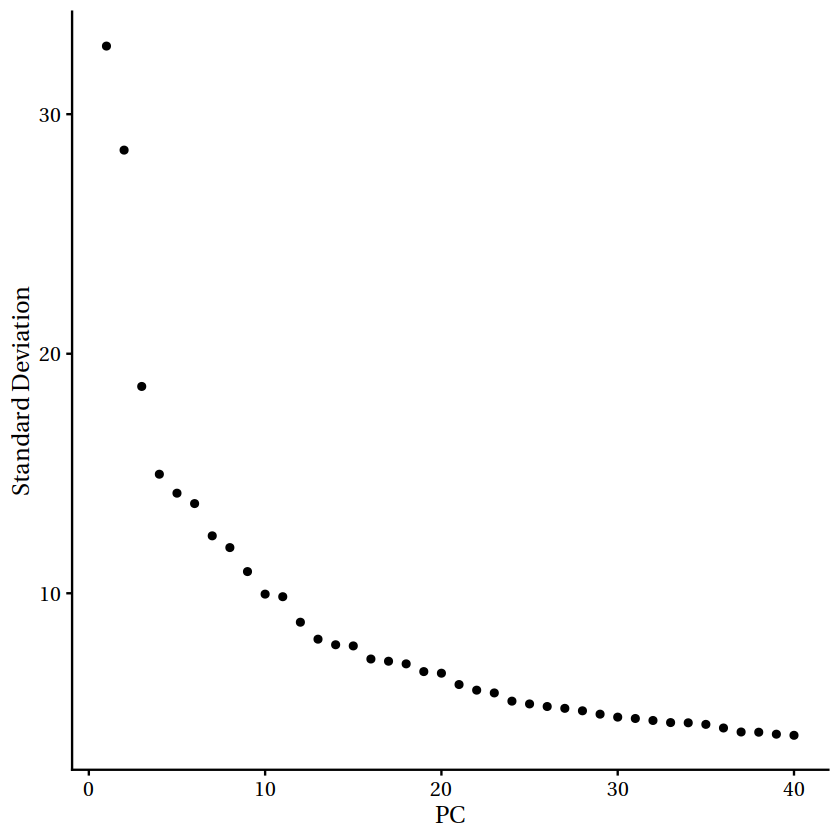

In [11]:
hvg <- read.csv("cellplex2.bigsur.hvg.csv", row.names = 1)

obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


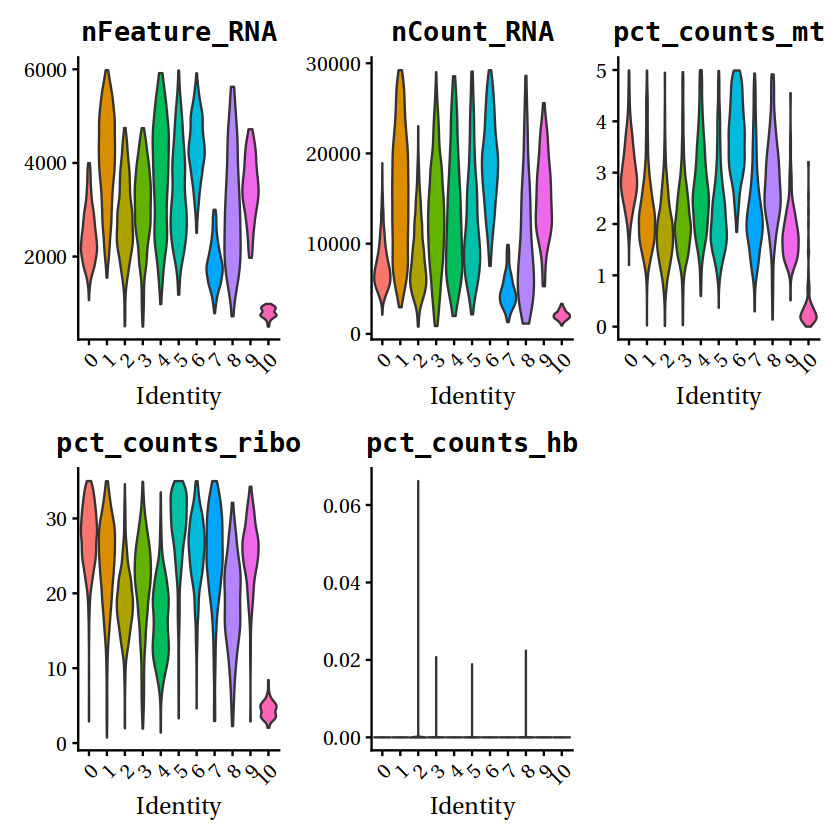

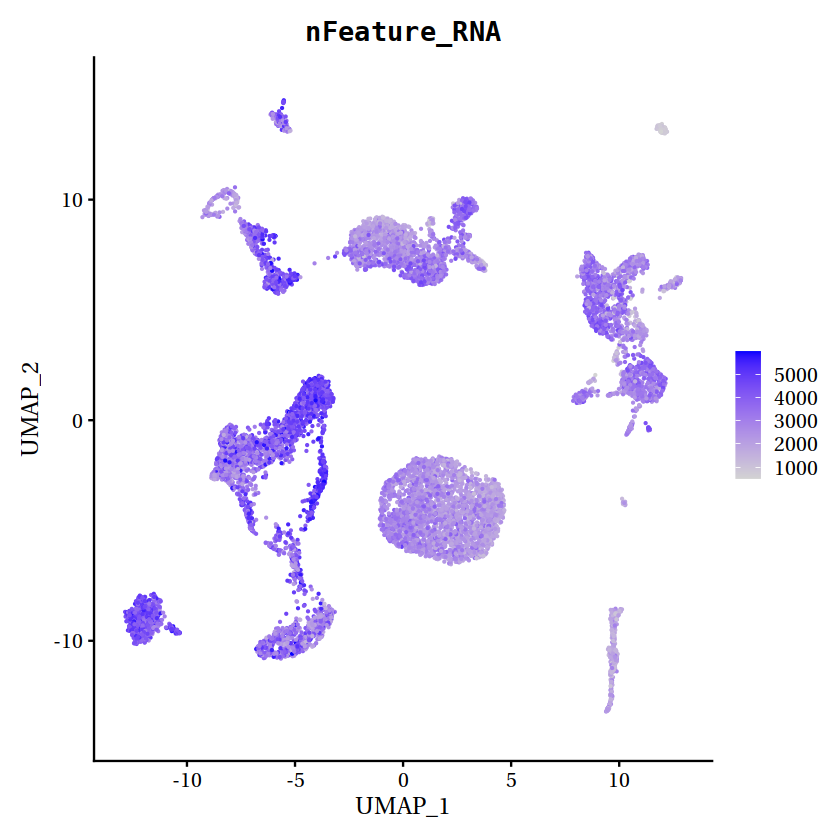

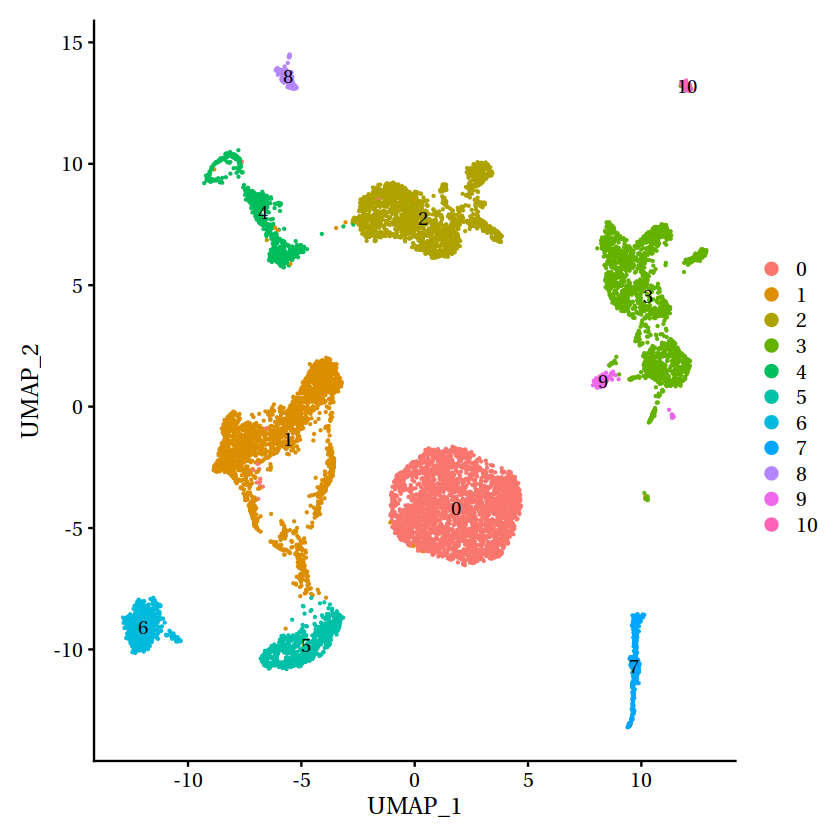

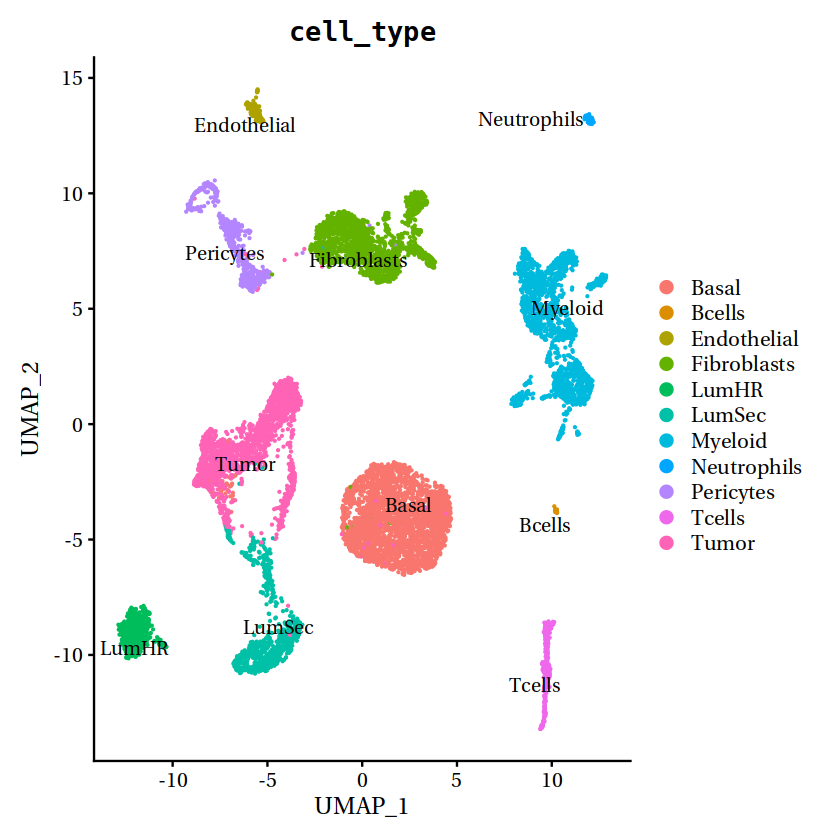

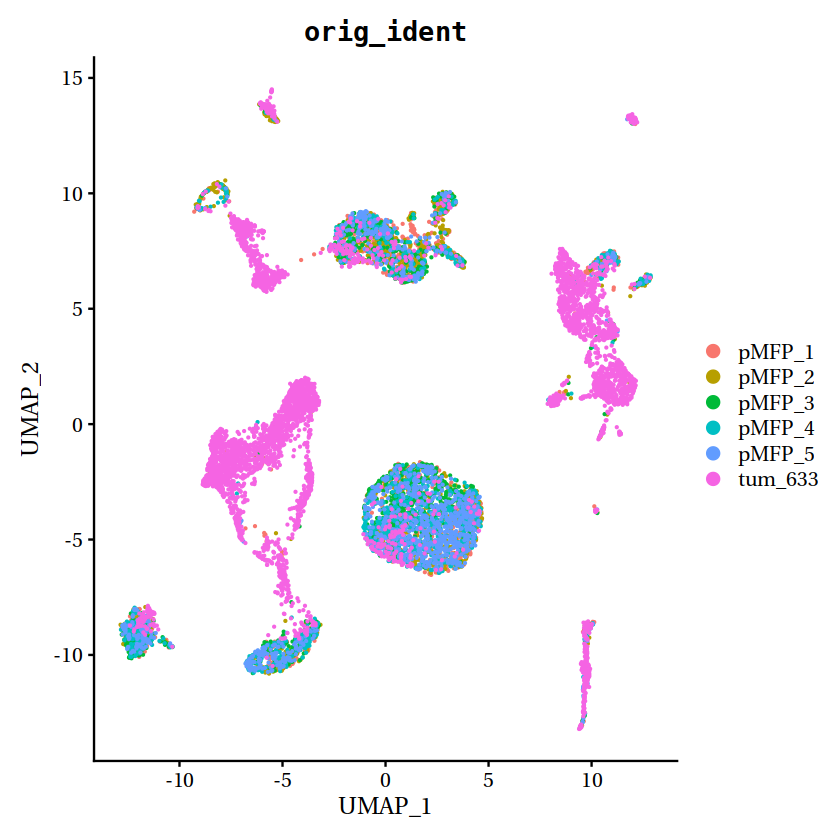

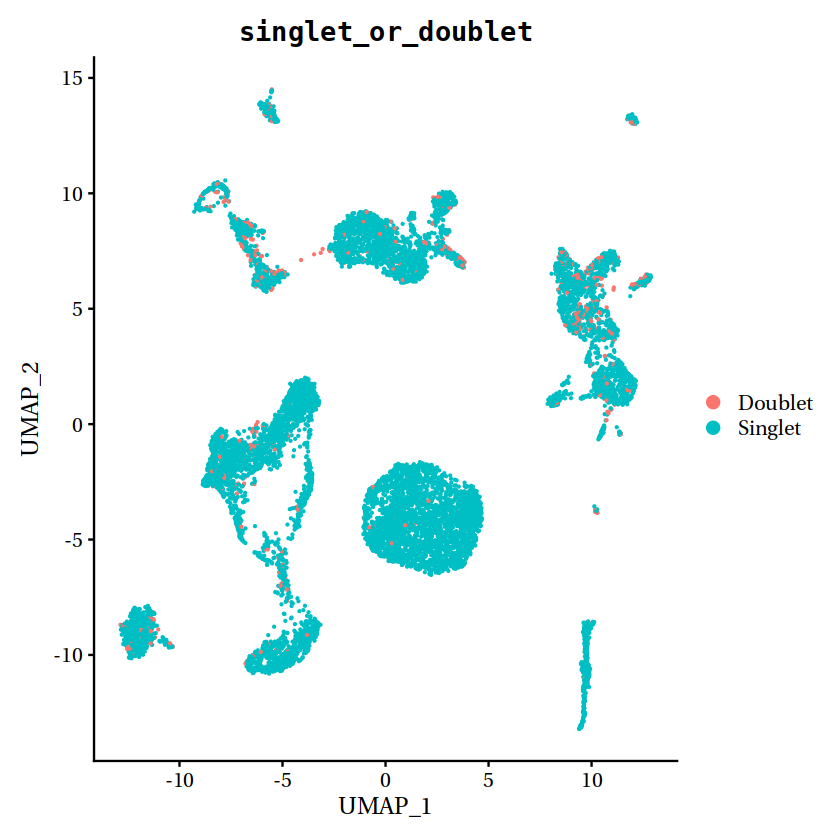

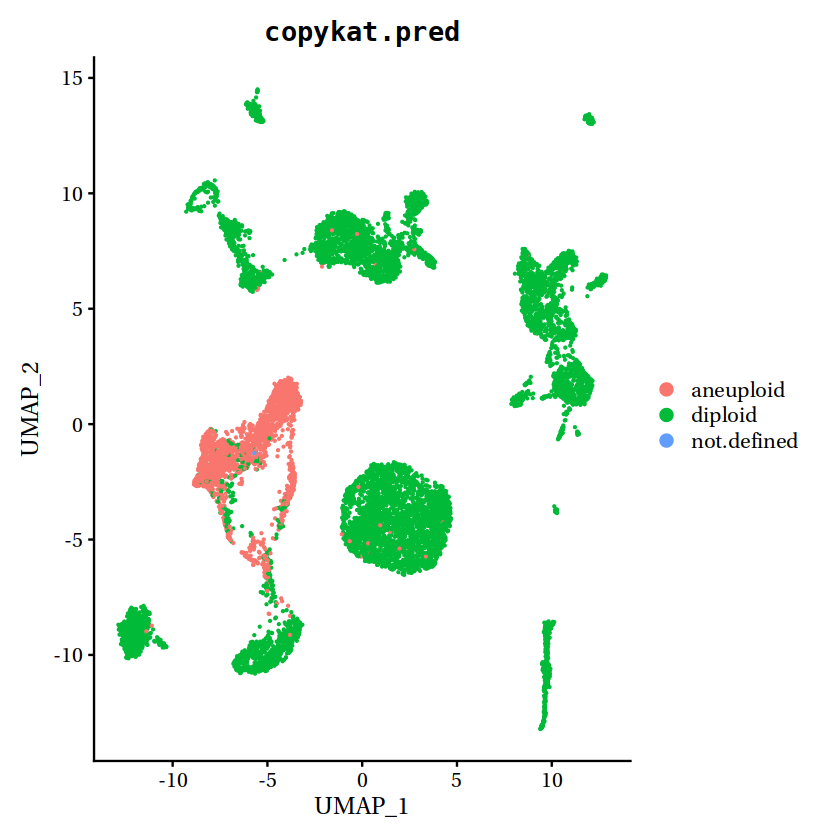

In [12]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)
DimPlot(obj, group.by = "singlet_or_doublet", label = F)
DimPlot(obj, group.by = "copykat.pred", label = F)

In [13]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Basal", 
                            `1` = "Tumor", 
                            `2` = "Fibroblasts", 
                            `3` = "Myeloid",
                            `4` = "Pericytes",
                            `5` = "LumSec",
                            `6` = "LumHR", 
                            `7` = "Tcells", 
                            `8` = "Endothelial", 
                            `9` = "Myeloid",
                            `10` = "Neutrophils")
obj$cell_type <- obj@active.ident

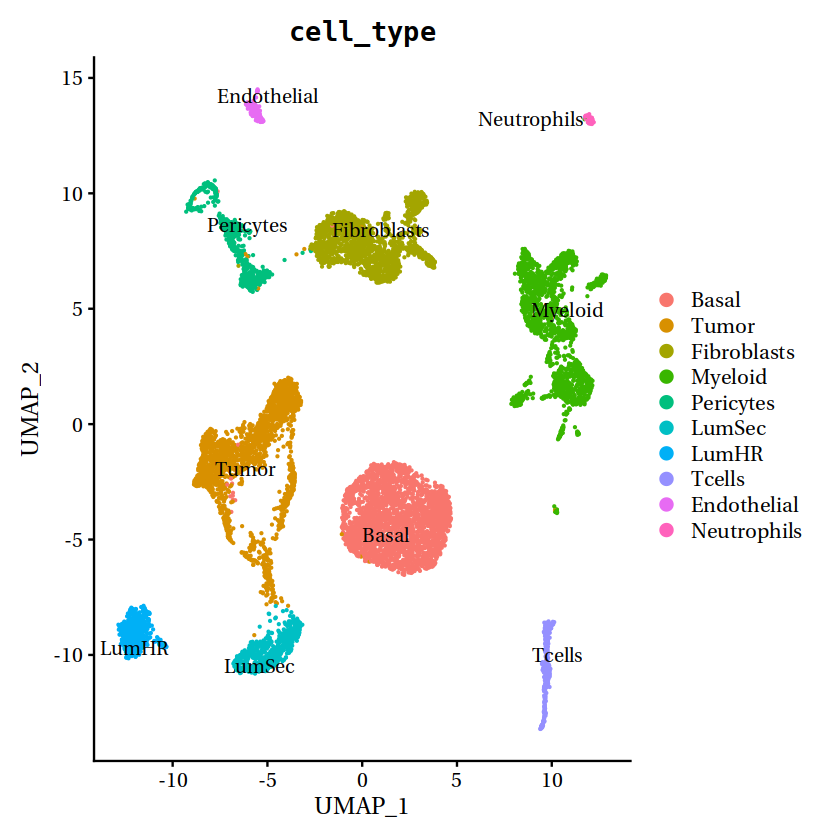

In [14]:
DimPlot(obj, group.by = "cell_type", label = T, repel = T)

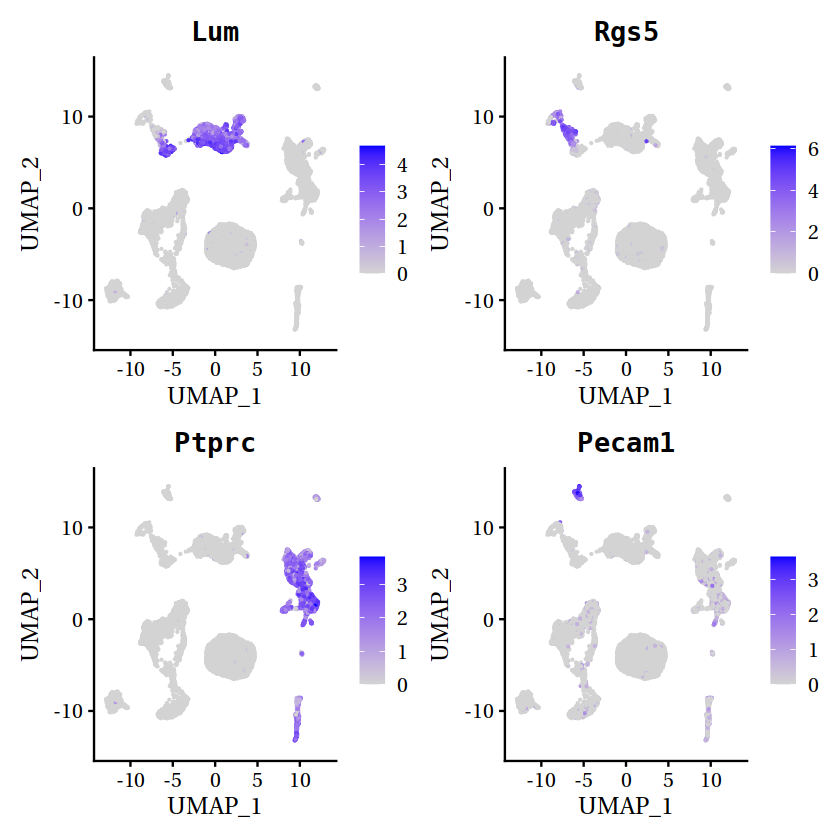

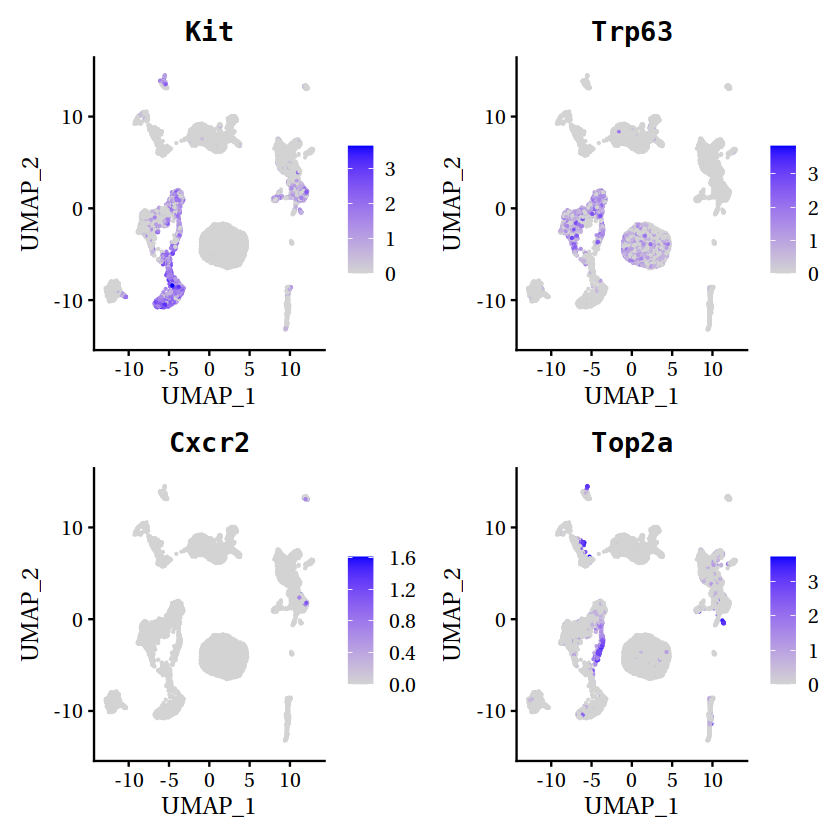

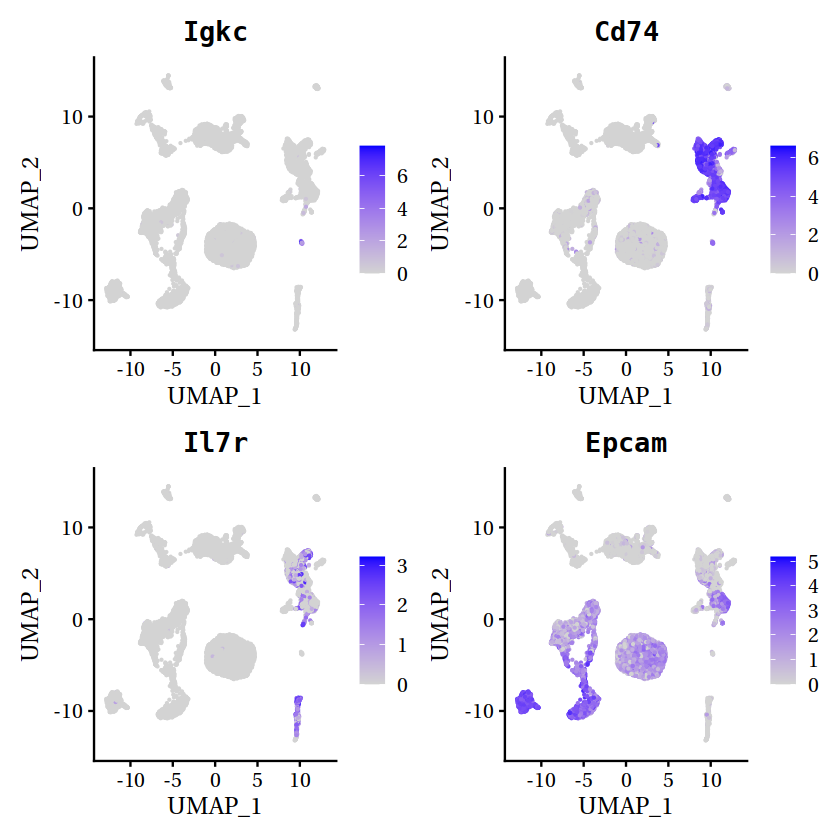

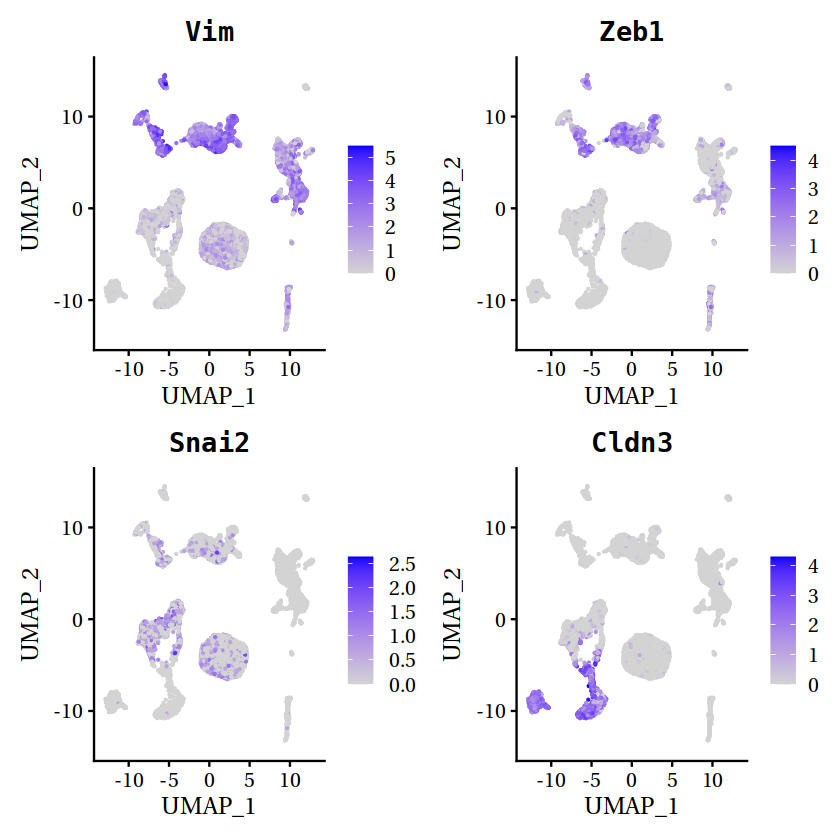

In [15]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

### add important metadata

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

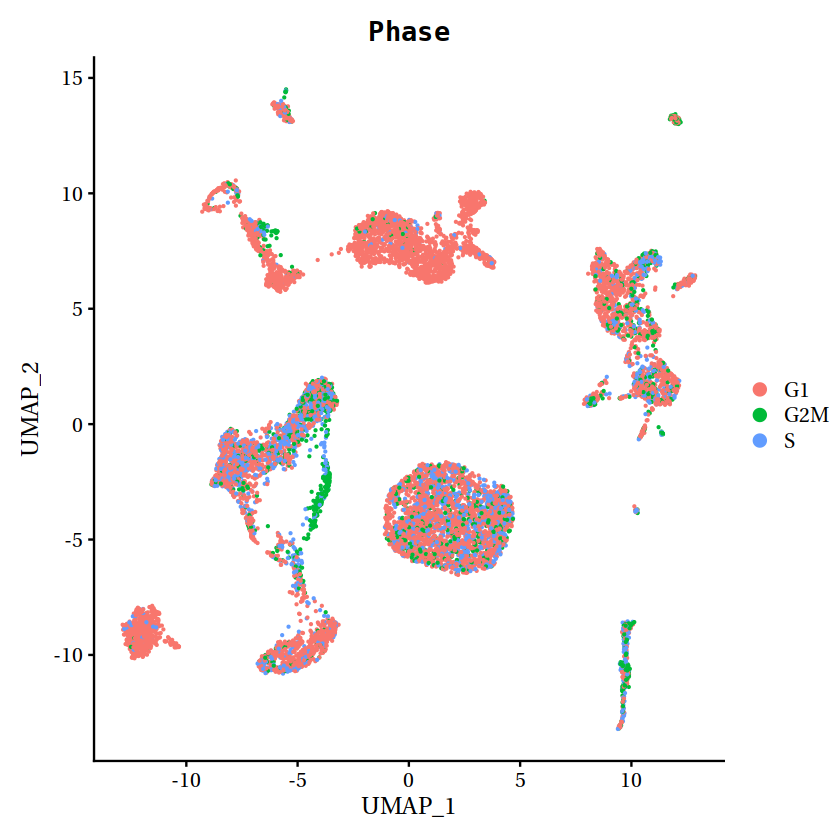

In [16]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

In [17]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Epithelial", 
                            `2` = "Stromal", 
                            `3` = "Immune",
                            `4` = "Stromal",
                            `5` = "Epithelial",
                            `6` = "Epithelial", 
                            `7` = "Immune", 
                            `8` = "Stromal", 
                            `9` = "Immune",
                            `10` = "Immune")
obj$cell_type_group <- obj@active.ident

In [18]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `pMFP_1` = "mutant", 
                            `pMFP_2` = "mutant", 
                            `pMFP_3` = "mutant",
                            `pMFP_4` = "mutant",
                            `pMFP_5` = "mutant",
                            `tum_633` = "mutant")
obj$genotype <- obj@active.ident

In [19]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `pMFP_1` = "mutant", 
                            `pMFP_2` = "mutant", 
                            `pMFP_3` = "mutant",
                            `pMFP_4` = "mutant",
                            `pMFP_5` = "mutant",
                            `tum_633` = "tumor_unrelated")
obj$condition_metastatic_burden <- obj@active.ident

In [20]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `pMFP_1` = "mutant", 
                            `pMFP_2` = "mutant", 
                            `pMFP_3` = "mutant",
                            `pMFP_4` = "mutant",
                            `pMFP_5` = "mutant",
                            `tum_633` = "tumor_2mm")
obj$condition_tumor_size_mm <- obj@active.ident

In [21]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `pMFP_1` = "mutant", 
                            `pMFP_2` = "mutant", 
                            `pMFP_3` = "mutant",
                            `pMFP_4` = "mutant",
                            `pMFP_5` = "mutant",
                            `tum_633` = "tumor")
obj$condition <- obj@active.ident

In [22]:
obj$cellplex <- "2"
obj$organ <- "mammary"
obj$transplant_status <- "original"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [23]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `pMFP_1` = "removed", 
                            `pMFP_2` = "removed", 
                            `pMFP_3` = "removed",
                            `pMFP_4` = "removed",
                            `pMFP_5` = "removed",
                            `tum_633` = "removed")
obj$lymph_node_presence <- obj@active.ident

In [24]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `pMFP_1` = "mutant_1", 
                            `pMFP_2` = "mutant_1", 
                            `pMFP_3` = "mutant_1",
                            `pMFP_4` = "mutant_1",
                            `pMFP_5` = "mutant_1",
                            `tum_633` = "tumor_2")
obj$mouse <- obj@active.ident

In [25]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [26]:
obj$S.Score <- NULL
obj$G2M.Score <- NULL
obj$SCT_snn_res.0.1 <- NULL

In [27]:
meta <- read.csv("cellplex2.adata.obs.metadata.csv", row.names=1)
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [28]:
saveRDS(obj, "cellplex2_soupX_doubletfinder_cnv_metadata.rds")

In [3]:
obj <- readRDS("cellplex2_soupX_doubletfinder_cnv_metadata.rds")

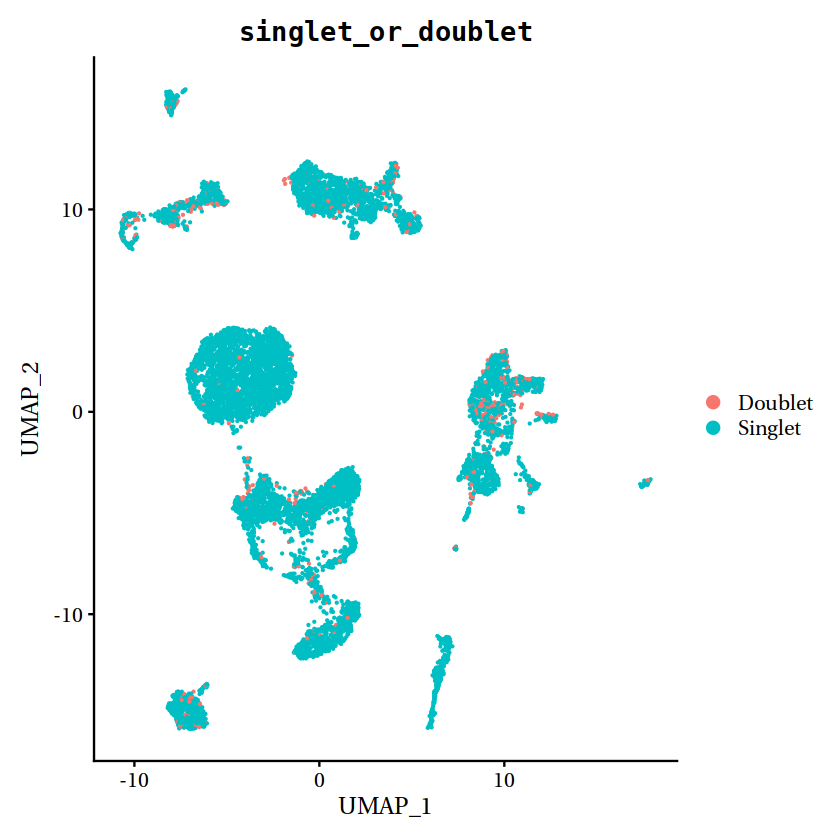

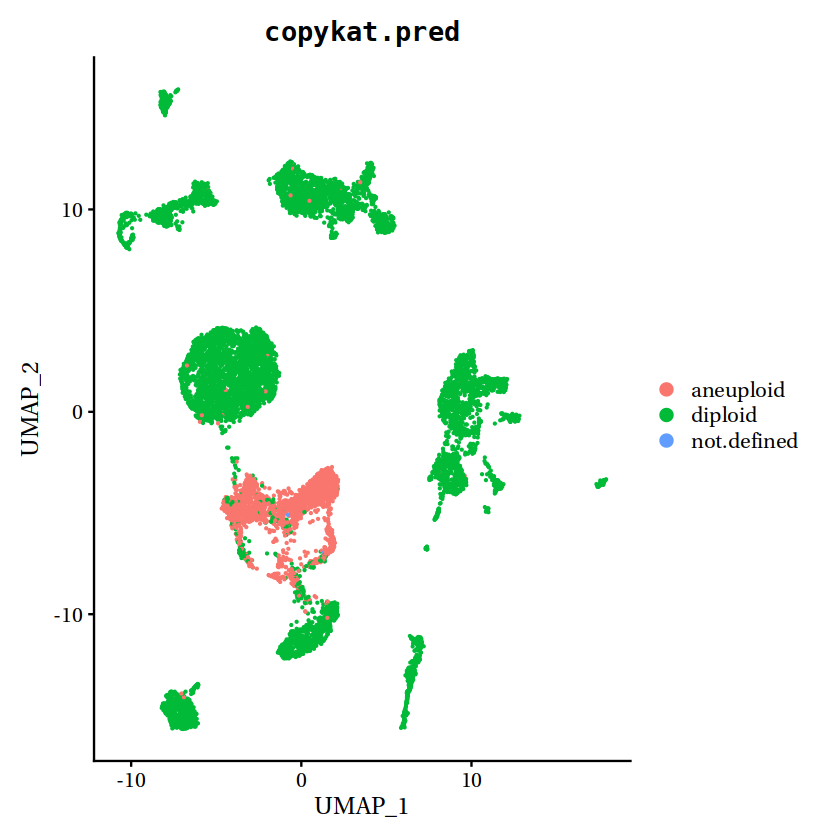

In [4]:
pred <- read.csv("cellplex_2_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

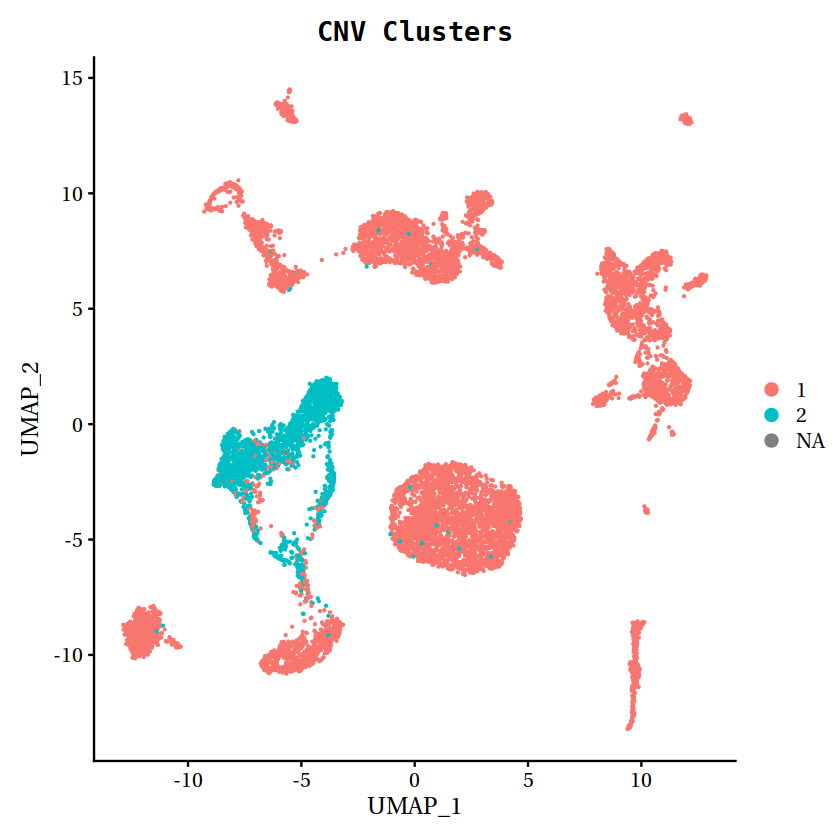

In [30]:
clust_res <- readRDS("cellplex_2_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 2, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

In [6]:
saveRDS(obj, "cellplex2_soupX_doubletfinder_cnv_metadata.rds")